## 0. Constants/Imports

In [10]:
import uproot
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys,os
import argparse
from tqdm import tqdm

#CAFPYANA working directory
CAFPYANA_WD = '/exp/sbnd/app/users/brindenc/develop/cafpyana'
os.environ['CAFPYANA_WD'] = CAFPYANA_WD

cafpyana_wd = os.environ.get('CAFPYANA_WD')
if cafpyana_wd and cafpyana_wd not in sys.path:
    sys.path.insert(0, cafpyana_wd)
    sys.path.insert(0, cafpyana_wd + '/pyanalib')

#My imports 
SBNDANA_DIR = '/exp/sbnd/app/users/brindenc/develop/cafpyana/analysis_village/numuincl/sbnd'
WIENER_DIR = '/exp/sbnd/app/users/brindenc/develop/cafpyana/analysis_village/unfolding'
sys.path.insert(0,SBNDANA_DIR)
sys.path.insert(0,f'{SBNDANA_DIR.replace("/numuincl/sbnd","/numuincl")}')
sys.path.insert(0,WIENER_DIR)
plt.style.use(f'{SBNDANA_DIR}/plotlibrary/numu2025.mplstyle')

#My imports
from sbnd.cafclasses.slice import CAFSlice
from sbnd.constants import *
from sbnd.numu.numu_constants import *
from sbnd.detector.definitions import * # >= v2.2
from sbnd.general import plotters
from sbnd.general.utils import convert_pnfs_to_xroot,h5py_file_xrootd,read_hdf_xrootd
from naming import *
from sbnd.stats.systematics import Systematics

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
from datetime import date
day = date.today().strftime("%Y_%m_%d")

BASE_DIR = '/exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora'
PNFS_BASE_DIR = '/pnfs/sbnd/persistent/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora'
PLOT_DIR = f'{BASE_DIR}/plots/{day}'
VERSION = 'v5'

MC_FNAME = f'{BASE_DIR}/mc_syst/{VERSION}/mc_smallpand_fullsyst_cut_norecomb3.df'
MC_LOWE_FNAME = f'{BASE_DIR}/mc_lowe/{VERSION}/mc_smallpand_fullsyst_cut_norecomb3.df'

OFFBEAM_FNAME = f'{BASE_DIR}/offbeam/{VERSION}/mc_smallpand_nosyst_nocuts_recomb3.df'
DATA_FNAME = f'{BASE_DIR}/data/{VERSION}/dataonbeam_nocuts3.df'

FLUX_FILE = '/exp/sbnd/data/users/munjung/flux/sbnd_original_flux.root'

In [3]:
day

'2026_01_28'

In [4]:
NUMBER_TARGETS_FV

5.079980638121578e+31

## 1. Load data

In [5]:
# Get keys for h5 files
import h5py
mcnu_keys = []
mcnu_lowe_keys = []


#Slices - signal
mc_signal_pand_keys = []
mc_signal_lowe_pand_keys = []

#Slices - selected
mc_selected_pand_keys = []
mc_selected_lowe_pand_keys = []

#Slices
offbeam_pand_keys = []
data_pand_keys = []

#Tracks
mc_trk_keys = []
mc_lowe_trk_keys = []
offbeam_trk_keys = []
data_trk_keys = []

#Headers
hdr_keys = []
mc_lowe_hdr_keys = []
offbeam_hdr_keys = []
data_hdr_keys = []

#POT and total event keys
mc_pot_keys = []
mc_lowe_pot_keys = []
offbeam_pot_keys = []
data_pot_keys = []

mc_genevt_keys = []
mc_lowe_genevt_keys = []
offbeam_genevt_keys = []
data_genevt_keys = []
# Check the keys in the H5 Files
for fname in [MC_FNAME,OFFBEAM_FNAME,DATA_FNAME,MC_LOWE_FNAME]:
  print(f'File: {fname}')
  with h5py_file_xrootd(f'{fname}', 'r') as f:
    # Store all keys at the root level
    print(f.keys())
    for key in f.keys():
      if 'pand' in key:
        if fname == MC_FNAME:
          if 'signal' in key:
            mc_signal_pand_keys.append(key)
          elif 'selected' in key:
            mc_selected_pand_keys.append(key)
          else:
            mc_pand_keys.append(key)
        elif fname == OFFBEAM_FNAME:
          offbeam_pand_keys.append(key)
        elif fname == DATA_FNAME:
          data_pand_keys.append(key)
        elif fname == MC_LOWE_FNAME:
          if 'signal' in key:
            mc_signal_lowe_pand_keys.append(key)
          elif 'selected' in key:
            mc_selected_lowe_pand_keys.append(key)
          else:
            mc_lowe_pand_keys.append(key)
      elif 'trk' in key:
        if fname == MC_FNAME:
          mc_trk_keys.append(key)
        elif fname == OFFBEAM_FNAME:
          offbeam_trk_keys.append(key)
        elif fname == DATA_FNAME:
          data_trk_keys.append(key)
        elif fname == MC_LOWE_FNAME:
          mc_lowe_trk_keys.append(key)
      elif 'mcnu' in key:
        if fname == MC_FNAME:
          mcnu_keys.append(key)
        elif fname == MC_LOWE_FNAME:
          mcnu_lowe_keys.append(key)
      elif 'hdr' in key:
        if fname == MC_FNAME:
          hdr_keys.append(key)
        elif fname == OFFBEAM_FNAME:
          offbeam_hdr_keys.append(key)
        elif fname == DATA_FNAME:
          data_hdr_keys.append(key)
        elif fname == MC_LOWE_FNAME:
          mc_lowe_hdr_keys.append(key)
      elif 'histpotdf' in key:
        if fname == MC_FNAME:
          mc_pot_keys.append(key)
        elif fname == OFFBEAM_FNAME:
          offbeam_pot_keys.append(key)
        elif fname == DATA_FNAME:
          data_pot_keys.append(key)
        elif fname == MC_LOWE_FNAME:
          mc_lowe_pot_keys.append(key)
      elif 'histgenevtdf' in key:
        if fname == MC_FNAME:
          mc_genevt_keys.append(key)
        elif fname == OFFBEAM_FNAME:
          offbeam_genevt_keys.append(key)
        elif fname == DATA_FNAME:
          data_genevt_keys.append(key)
        elif fname == MC_LOWE_FNAME:
          mc_lowe_genevt_keys.append(key)

File: /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/mc_syst/v5/mc_smallpand_fullsyst_cut_norecomb3.df
<KeysViewHDF5 ['split']>
File: /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/offbeam/v5/mc_smallpand_nosyst_nocuts_recomb3.df
<KeysViewHDF5 ['evt_pand_0', 'hdr_0', 'histgenevtdf_0', 'histpotdf_0', 'mcnu_0', 'split', 'trk_0']>
File: /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/data/v5/dataonbeam_nocuts3.df
<KeysViewHDF5 ['evt_pand_0', 'evt_pand_1', 'hdr_0', 'hdr_1', 'histgenevtdf_0', 'histgenevtdf_1', 'histpotdf_0', 'histpotdf_1', 'mcnu_0', 'mcnu_1', 'split', 'trk_0', 'trk_1']>
File: /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/mc_lowe/v5/mc_smallpand_fullsyst_cut_norecomb3.df
<KeysViewHDF5 ['split']>


In [6]:
mc_pot_keys

[]

In [7]:
#Get POT from the h5
POT_MC = 0
for key in mc_pot_keys:
  potdf_mc = read_hdf_xrootd(MC_FNAME,key=key)
  POT_MC += potdf_mc.TotalPOT.values.sum()
print(f'POT_MC: {POT_MC:.2e}')

POT_MC_LOWE = 0
for key in mc_lowe_pot_keys:
  potdf_mc_lowe = read_hdf_xrootd(MC_LOWE_FNAME,key=key)
  POT_MC_LOWE += potdf_mc_lowe.TotalPOT.values.sum()
# for key in mc_lowe_hdr_keys:
#   potdf_mc_lowe = read_hdf_xrootd(MC_LOWE_FNAME,key=key)
#   POT_MC_LOWE += potdf_mc_lowe.pot.values.sum()
print(f'POT_MC_LOWE: {POT_MC_LOWE:.2e}')

LIVETIME_OFFBEAM = 0
for key in offbeam_genevt_keys:
  genevt_offbeam = read_hdf_xrootd(OFFBEAM_FNAME,key=key)
  LIVETIME_OFFBEAM += genevt_offbeam.TotalGenEvents.values.sum()
# for key in offbeam_hdr_keys:
#   hdr_offbeam = read_hdf_xrootd(OFFBEAM_FNAME,key=key)
#   LIVETIME_OFFBEAM += hdr_offbeam.ngenevt.values.sum()
print(f'LIVETIME_OFFBEAM: {LIVETIME_OFFBEAM:.2e}')

LIVETIME_DATA = 0
POT_DATA = 0
for key in data_hdr_keys:
  hdr_data = read_hdf_xrootd(DATA_FNAME,key=key)
  LIVETIME_DATA += hdr_data.noffbeambnb.values.sum()
  POT_DATA += hdr_data.pot.values.sum()
LIVETIME_DATA = 9.51e5 # Temporary
print(f'LIVETIME_DATA: {LIVETIME_DATA:.2e}')
print(f'POT_DATA: {POT_DATA:.2e}')
POT_LABEL = f'{POT_DATA:.2e} POT'

POT_MC: 0.00e+00
POT_MC_LOWE: 0.00e+00


LIVETIME_OFFBEAM: 4.89e+05
LIVETIME_DATA: 9.51e+05
POT_DATA: 5.95e+18


In [42]:
#Selected
# slc_mc_sel = CAFSlice.load(MC_FNAME,key=mc_selected_pand_keys,filter_univ=False)
# slc_lowe_sel = CAFSlice.load(MC_LOWE_FNAME,key=mc_selected_lowe_pand_keys,filter_univ=False)
# slc_offbeam_sel = CAFSlice.load(OFFBEAM_FNAME,key=offbeam_pand_keys,filter_univ=False)

# #Signal
# slc_mc_signal = CAFSlice.load(MC_FNAME,key=mc_signal_pand_keys,filter_univ=False)
# slc_lowe_signal = CAFSlice.load(MC_LOWE_FNAME,key=mc_signal_lowe_pand_keys,filter_univ=False)
# slc_offbeam_signal = CAFSlice.load(OFFBEAM_FNAME,key=offbeam_pand_keys,filter_univ=False)

#Data
slc_data = CAFSlice.load(DATA_FNAME,key=data_pand_keys)

In [43]:
slc_data.cut_all(cut=True)

### 1.1 Rescale to MC POT (optional)

In [ ]:
# Rescale to POT_DATA
slc_mc_sel.scale_to_pot(POT_DATA,sample_pot=POT_MC)
slc_lowe_sel.scale_to_pot(POT_DATA,sample_pot=POT_MC_LOWE)
slc_offbeam_sel.scale_to_livetime(LIVETIME_DATA,sample_livetime=LIVETIME_OFFBEAM)

slc_mc_signal.scale_to_pot(POT_DATA,sample_pot=POT_MC)
slc_lowe_signal.scale_to_pot(POT_DATA,sample_pot=POT_MC_LOWE)
slc_offbeam_signal.scale_to_livetime(LIVETIME_DATA,sample_livetime=LIVETIME_OFFBEAM)

--scaling to POT (3.97e+00): 1.50e+18 -> 5.95e+18
--scaling to POT (9.89e-01): 6.01e+18 -> 5.95e+18
--scaling to livetime (9.65e+00): 9.85e+04 --> 9.51e+05
--scaling to POT (3.96e+00): 1.50e+18 -> 5.95e+18
--scaling to POT (9.89e-01): 6.01e+18 -> 5.95e+18
--scaling to POT (3.97e+00): 1.50e+18 -> 5.95e+18
--scaling to POT (9.89e-01): 6.01e+18 -> 5.95e+18
--scaling to livetime (9.65e+00): 9.85e+04 --> 9.51e+05


In [ ]:
#Combine
# - selected
slc_mc_sel.combine(slc_lowe_sel,duplicate_ok=True)
del slc_lowe_sel
slc_offbeam_sel.cut_all(cut=True) #Apply cut to off beam since it's not applied (fix this later)
slc_mc_sel.combine(slc_offbeam_sel,duplicate_ok=True,offset=int(2e5))
del slc_offbeam_sel

slc_mc_signal.combine(slc_lowe_signal,duplicate_ok=True)
del slc_lowe_signal
# slc_mc_signal.combine(slc_offbeam_signal,duplicate_ok=True,offset=int(2e5))
# del slc_offbeam_signal

### 1.2 Assign binnings

In [ ]:
# Binning 2d class
from sbnd.cafclasses.binning import Binning2D
binning2d = Binning2D()

In [ ]:
costheta_bins = COSTHETA_BINS
momentum_bins = MOMENTUM_BINS

diff_momentum_bins = DIFF_MOMENTUM_BINS
diff_costheta_bins = DIFF_COSTHETA_BINS

costheta_bin_widths = np.diff(costheta_bins)
momentum_bin_widths = np.diff(momentum_bins)

diff_momentum_bin_widths = np.diff(diff_momentum_bins)
diff_costheta_bin_widths = np.diff(diff_costheta_bins)

costheta_centers = (costheta_bins[:-1] + costheta_bins[1:])/2.
momentum_centers = (momentum_bins[:-1] + momentum_bins[1:])/2.
momentum_centers[-1] = 3.5 #Because the last bin is enormous

diff_momentum_centers = (binning2d.diff_momentum_bins[:-1] + binning2d.diff_momentum_bins[1:])/2.
diff_costheta_centers = (binning2d.diff_costheta_bins[:-1] + binning2d.diff_costheta_bins[1:])/2.
diff_momentum_centers[-1] = 3.5 #Because the last bin is enormous

differential_bins = binning2d.differential_bins
differential_centers = binning2d.differential_centers
differential_edges = binning2d.differential_edges
differential_dicts = binning2d.differential_dicts



1.0
Missing true bin: [False False False ... False False False]


Generating event seeds: 100%|██████████| 4047/4047 [00:00<00:00, 111228.43it/s]


Successfully generated 4047 unique seeds


Generating universes: 100%|██████████| 100/100 [00:01<00:00, 74.39it/s]


0.04398319743019521
Missing true bin: [ True  True  True ...  True  True  True]


...

Missing true bin: [ True  True  True ...  True  True  True]


Generating event seeds: 100%|██████████| 373249/373249 [00:03<00:00, 112956.64it/s]


Successfully generated 373249 unique seeds


Generating universes: 100%|██████████| 100/100 [02:04<00:00,  1.24s/it]


0.9622530803833366
Missing true bin: [ True False False ... False False False]


In [ ]:
#This should be empty
m1 = slc_mc_sel.data.true_bin.differential == -1
assert len(slc_mc_sel.data[m1]) == 0, f'{len(slc_mc_sel.data[m1])} slices have no differential bin'

In [ ]:
#Smallest 5 bin counnts
slc_mc_sel.data.true_bin.differential.value_counts().values[-5:]

array([4, 4, 1, 1, 1])

### 1.2 Extract selected signal

In [ ]:
is_signal = np.isin(slc_mc_sel.data.truth.event_type,[0,1])
slc_mc_sel_signal = CAFSlice(slc_mc_sel.data[is_signal])
slc_mc_sel_background = CAFSlice(slc_mc_sel.data[~is_signal])

In [ ]:
m1 = slc_mc_sel_background.data.bin.costheta == -1
slc_mc_sel_background.data[m1].has_muon

Series([], Name: has_muon, dtype: object)

### 1.3 Flux

In [ ]:
# Extract flux from the flux file
flux = uproot.open(FLUX_FILE)

# numu flux
numu_flux = flux["flux_sbnd_numu"].to_numpy()
bin_edges = numu_flux[1]
flux_vals = numu_flux[0]

# get integrated flux
integrated_flux = flux_vals.sum()
integrated_flux /= 1e4 # to cm2
INTEGRATED_FLUX = np.float64(integrated_flux * POT_DATA / 1e6) # POT
print("Integrated flux: %.3e" % INTEGRATED_FLUX)

Integrated flux: 9.608e+10


In [ ]:
integrated_flux*1e2

1.6148681640625

In [ ]:
#XSEC_UNIT = 1/ (INTEGRATED_FLUX * NTARGETS)
XSEC_UNIT = 1/ (INTEGRATED_FLUX * NUMBER_TARGETS_FV)
print(f'Xsec unit: {XSEC_UNIT}')

Xsec unit: 2.0488476918781626e-43


### 1.4 Get binnings

In [ ]:
#Selected
genweights = slc_mc_sel.data.genweight.values

reco_costheta = slc_mc_sel.data.mu.pfp.trk.costheta
reco_costheta_bin = slc_mc_sel.data.bin.costheta
true_costheta = slc_mc_sel.data.truth.mu.dir.z
true_costheta_bin = slc_mc_sel.data.true_bin.costheta
#Fix the costheta for selected slices that don't have a true muon
m1 = true_costheta == -1
true_costheta[m1] = slc_mc_sel.data.mu.pfp.trk.truth.p.dir.z[m1]
data_costheta = slc_data.data.mu.pfp.trk.costheta
data_costheta_bin = slc_data.data.bin.costheta

reco_momentum = slc_mc_sel.data.mu.pfp.trk.P.p_muon
reco_momentum_bin = slc_mc_sel.data.bin.momentum
true_momentum = slc_mc_sel.data.truth.mu.totp
true_momentum_bin = slc_mc_sel.data.true_bin.momentum
#Fix the momentum for selected slices that don't have a true muon
m1 = true_momentum == -1
true_momentum[m1] = slc_mc_sel.data.mu.pfp.trk.truth.p.totp[m1]

data_momentum = slc_data.data.mu.pfp.trk.P.p_muon
data_momentum_bin = slc_data.data.bin.momentum

reco_differential = slc_mc_sel.data.bin.differential
true_differential = slc_mc_sel.data.true_bin.differential
data_differential = slc_data.data.bin.differential

#Selected signal
genweights_sel = slc_mc_sel_signal.data.genweight.values

reco_sel_costheta = slc_mc_sel_signal.data.mu.pfp.trk.costheta
reco_sel_costheta_bin = slc_mc_sel_signal.data.bin.costheta
true_sel_costheta = slc_mc_sel_signal.data.truth.mu.dir.z
true_sel_costheta_bin = slc_mc_sel_signal.data.true_bin.costheta
#Fix the costheta for selected slices that don't have a true muon
m1 = true_sel_costheta == -1
true_sel_costheta[m1] = slc_mc_sel_signal.data.mu.pfp.trk.truth.p.dir.z[m1]

data_sel_costheta = slc_data.data.mu.pfp.trk.costheta
data_sel_costheta_bin = slc_data.data.bin.costheta

reco_sel_momentum = slc_mc_sel_signal.data.mu.pfp.trk.P.p_muon
reco_sel_momentum_bin = slc_mc_sel_signal.data.bin.momentum
true_sel_momentum = slc_mc_sel_signal.data.truth.mu.totp
true_sel_momentum_bin = slc_mc_sel_signal.data.true_bin.momentum
#Fix the momentum for selected slices that don't have a true muon
m1 = true_sel_momentum == -1
true_sel_momentum[m1] = slc_mc_sel_signal.data.mu.pfp.trk.truth.p.totp[m1]
data_sel_momentum = slc_data.data.mu.pfp.trk.P.p_muon
data_sel_momentum_bin = slc_data.data.bin.momentum

reco_sel_differential = slc_mc_sel_signal.data.bin.differential
true_sel_differential = slc_mc_sel_signal.data.true_bin.differential

#Selected background
genweights_sel_background = slc_mc_sel_background.data.genweight.values

reco_sel_background_costheta = slc_mc_sel_background.data.mu.pfp.trk.costheta
reco_sel_background_costheta_bin = slc_mc_sel_background.data.bin.costheta
true_sel_background_costheta = slc_mc_sel_background.data.truth.mu.dir.z
true_sel_background_costheta_bin = slc_mc_sel_background.data.true_bin.costheta
#Fix the costheta for selected slices that don't have a true muon
m1 = true_sel_background_costheta == -1
true_sel_background_costheta[m1] = slc_mc_sel_background.data.mu.pfp.trk.truth.p.dir.z[m1]

reco_sel_background_momentum = slc_mc_sel_background.data.mu.pfp.trk.P.p_muon
reco_sel_background_momentum_bin = slc_mc_sel_background.data.bin.momentum
true_sel_background_momentum = slc_mc_sel_background.data.truth.mu.totp
true_sel_background_momentum_bin = slc_mc_sel_background.data.true_bin.momentum
#Fix the momentum for selected slices that don't have a true muon
m1 = true_sel_background_momentum == -1
true_sel_background_momentum[m1] = slc_mc_sel_background.data.mu.pfp.trk.truth.p.totp[m1]

reco_sel_background_differential = slc_mc_sel_background.data.bin.differential
true_sel_background_differential = slc_mc_sel_background.data.true_bin.differential


#Signal
mask = slc_mc_signal.data.index.isin(slc_mc_signal.data.slc.tmatch.eff.groupby(level=[0,1]).idxmax().dropna())
slc_mc_signal.data = slc_mc_signal.data[mask] #mask out anything that isn't the best match

genweights_sig = slc_mc_signal.data.genweight.values
#SLC
reco_sig_costheta = slc_mc_signal.data.mu.pfp.trk.costheta
reco_sig_costheta_bin = slc_mc_signal.data.bin.costheta
true_sig_costheta = slc_mc_signal.data.truth.mu.dir.z
true_sig_costheta_bin = slc_mc_signal.data.true_bin.costheta
#Fix the costheta for selected slices that don't have a true muon (this should'nt happen for signal)
m1 = true_sig_costheta == -1
if np.sum(m1) > 0: print(f'Warning: {np.sum(m1)} signal slices have no true muon')
true_sig_costheta[m1] = slc_mc_signal.data.mu.pfp.trk.truth.p.dir.z[m1]

reco_sig_momentum = slc_mc_signal.data.mu.pfp.trk.P.p_muon
reco_sig_momentum_bin = slc_mc_signal.data.bin.momentum
true_sig_momentum = slc_mc_signal.data.truth.mu.totp
true_sig_momentum_bin = slc_mc_signal.data.true_bin.momentum
#Fix the momentum for selected slices that don't have a true muon (this should'nt happen for signal)
m1 = true_sig_momentum == -1
if np.sum(m1) > 0: print(f'Warning: {np.sum(m1)} signal slices have no true muon')
true_sig_momentum[m1] = slc_mc_signal.data.mu.pfp.trk.truth.p.totp[m1]

reco_sig_differential = slc_mc_signal.data.bin.differential
true_sig_differential = slc_mc_signal.data.true_bin.differential

#For plotting
label_y_shift = 0.

In [ ]:
np.sum(genweights_sel)/np.sum(genweights_sig)

0.6134029023316485

## 2. Response matrix

### 2.1 Efficiency and signal vs selected

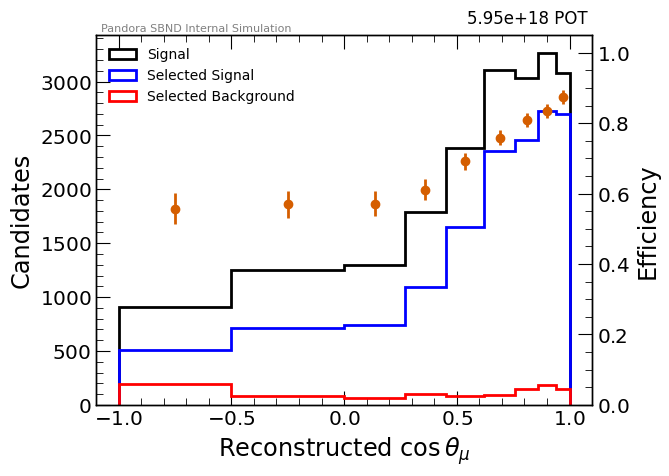

In [110]:
fig,ax = plt.subplots()
slc_costheta_sig,_,_ = ax.hist(reco_sig_costheta,bins=costheta_bins,weights=genweights_sig,label='Signal',histtype='step',color='black',alpha=1.)
slc_costheta_sel,_,_ = ax.hist(reco_sel_costheta,bins=costheta_bins,weights=genweights_sel,label='Selected Signal',histtype='step',color='blue',alpha=1.)
slc_costheta_sel_background,_,_ = ax.hist(reco_sel_background_costheta,bins=costheta_bins,weights=genweights_sel_background,label='Selected Background',histtype='step',color='red',alpha=1.)
slc_costheta_eff = slc_costheta_sel/slc_costheta_sig
assert np.nanmax(slc_costheta_eff) <= 1.0, f'Efficiency is greater than 100%: {np.nanmax(slc_costheta_eff)}'
ax2 = ax.twinx()
#ax2.scatter(costheta_centers,slc_costheta_eff,label='Efficiency')
ax2.errorbar(costheta_centers,slc_costheta_eff,yerr=1/np.sqrt(slc_costheta_sel),label='Efficiency',fmt='o')
ax.set_xlabel(r'Reconstructed $\cos\theta_{\mu}$')
ax.set_ylabel('Candidates')
ax2.set_ylim(0,1.05)
ax2.set_ylabel('Efficiency')

plotters.add_label(ax,PANDORA_QUALIFIER_INTERNAL_LABEL,where=(0.01,1.01+label_y_shift),fontsize=8,color='gray')
plotters.add_label(ax,POT_LABEL,where='toprightoutside',color='black',alpha=1.,fontsize=12)
ax.legend()

plotters.save_plot('reco_costheta_sel_signal_eff',fig=fig,folder_name=f'{PLOT_DIR}/pandora')

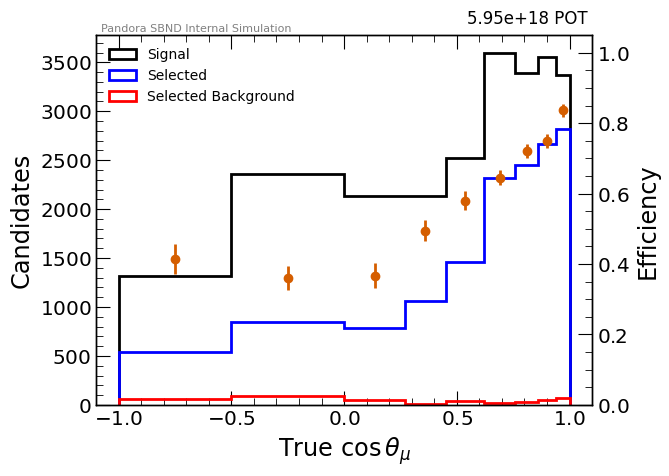

In [111]:
fig,ax = plt.subplots()
slc_costheta_sig_truth,_,_ = ax.hist(true_sig_costheta,bins=costheta_bins,weights=genweights_sig,label='Signal',histtype='step',color='black',alpha=1.)
slc_costheta_sel_truth,_,_ = ax.hist(true_sel_costheta,bins=costheta_bins,weights=genweights_sel,label='Selected',histtype='step',color='blue',alpha=1.)
slc_costheta_sel_background_truth,_,_ = ax.hist(true_sel_background_costheta,bins=costheta_bins,weights=genweights_sel_background,label='Selected Background',histtype='step',color='red',alpha=1.)
slc_costheta_eff_truth = slc_costheta_sel_truth/slc_costheta_sig_truth
assert np.nanmax(slc_costheta_eff) <= 1.0, f'Efficiency is greater than 100%: {np.nanmax(slc_costheta_eff)}'
ax2 = ax.twinx()
#ax2.scatter(costheta_centers,slc_costheta_eff_truth,label='Efficiency')
ax2.errorbar(costheta_centers,slc_costheta_eff_truth,yerr=1/np.sqrt(slc_costheta_sel_truth),label='Efficiency',fmt='o')
ax.set_xlabel(r'True $\cos\theta_{\mu}$')
ax.set_ylabel('Candidates')
ax2.set_ylim(0,1.05)
ax2.set_ylabel('Efficiency')

plotters.add_label(ax,PANDORA_QUALIFIER_INTERNAL_LABEL,where=(0.01,1.01+label_y_shift),fontsize=8,color='gray')
plotters.add_label(ax,POT_LABEL,where='toprightoutside',color='black',alpha=1.,fontsize=12)
ax.legend()

plotters.save_plot('truth_costheta_sel_signal_eff',fig=fig,folder_name=f'{PLOT_DIR}/pandora')

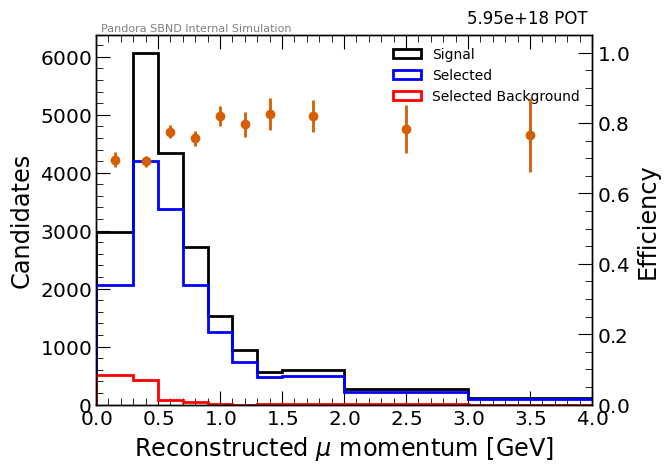

In [112]:
fig,ax = plt.subplots()
slc_momentum_sig,_,_ = ax.hist(reco_sig_momentum,bins=momentum_bins,weights=genweights_sig,label='Signal',histtype='step',color='black',alpha=1.)
slc_momentum_sel,_,_ = ax.hist(reco_sel_momentum,bins=momentum_bins,weights=genweights_sel,label='Selected',histtype='step',color='blue',alpha=1.)
slc_momentum_sel_background,_,_ = ax.hist(reco_sel_background_momentum,bins=momentum_bins,weights=genweights_sel_background,label='Selected Background',histtype='step',color='red',alpha=1.)
slc_momentum_eff = slc_momentum_sel/slc_momentum_sig
assert np.nanmax(slc_momentum_eff) <= 1.0, f'Efficiency is greater than 100%: {np.nanmax(slc_momentum_eff)}'
ax2 = ax.twinx()
#ax2.scatter(momentum_centers,slc_momentum_eff,label='Efficiency')
ax2.errorbar(momentum_centers,slc_momentum_eff,yerr=1/np.sqrt(slc_momentum_sel),label='Efficiency',fmt='o')
ax.set_xlabel(r'Reconstructed $\mu$ momentum [GeV]')
ax.set_ylabel('Candidates')
ax2.set_ylim(0,1.05)
ax.set_xlim(0,4.)
ax2.set_ylabel('Efficiency')

plotters.add_label(ax,PANDORA_QUALIFIER_INTERNAL_LABEL,where=(0.01,1.01+label_y_shift),fontsize=8,color='gray')
plotters.add_label(ax,POT_LABEL,where='toprightoutside',color='black',alpha=1.,fontsize=12)
ax.legend()

plotters.save_plot('reco_momentum_sel_signal_eff',fig=fig,folder_name=f'{PLOT_DIR}/pandora')

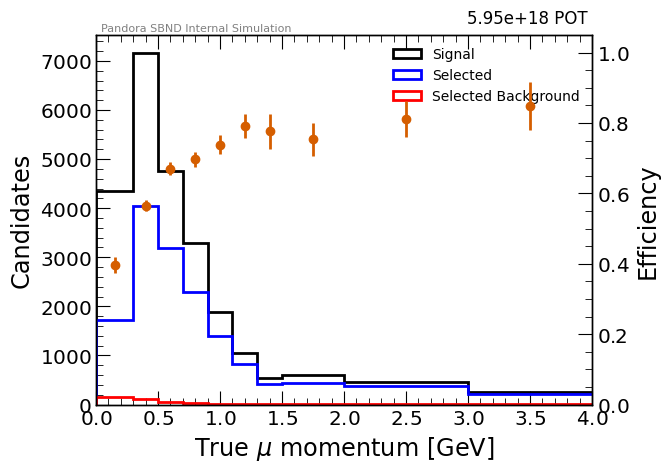

In [113]:
fig,ax = plt.subplots()
slc_momentum_sig_truth,_,_ = ax.hist(true_sig_momentum,bins=momentum_bins,weights=genweights_sig,label='Signal',histtype='step',color='black',alpha=1.)
slc_momentum_sel_truth,_,_ = ax.hist(true_sel_momentum,bins=momentum_bins,weights=genweights_sel,label='Selected',histtype='step',color='blue',alpha=1.)
slc_momentum_sel_background_truth,_,_ = ax.hist(true_sel_background_momentum,bins=momentum_bins,weights=genweights_sel_background,label='Selected Background',histtype='step',color='red',alpha=1.)
slc_momentum_eff_truth = slc_momentum_sel_truth/slc_momentum_sig_truth
assert np.nanmax(slc_momentum_eff) <= 1.0, f'Efficiency is greater than 100%: {np.nanmax(slc_momentum_eff)}'
ax2 = ax.twinx()
#ax2.scatter(momentum_centers,slc_momentum_eff_truth,label='Efficiency')
ax2.errorbar(momentum_centers,slc_momentum_eff_truth,yerr=1/np.sqrt(slc_momentum_sel_truth),label='Efficiency',fmt='o')
ax.set_xlabel(r'True $\mu$ momentum [GeV]')
ax.set_ylabel('Candidates')
ax2.set_ylim(0,1.05)
ax.set_xlim(0,4.)
ax2.set_ylabel('Efficiency')

plotters.add_label(ax,PANDORA_QUALIFIER_INTERNAL_LABEL,where=(0.01,1.01+label_y_shift),fontsize=8,color='gray')
plotters.add_label(ax,POT_LABEL,where='toprightoutside',color='black',alpha=1.,fontsize=12)
ax.legend()

plotters.save_plot('truth_momentum_sel_signal_eff',fig=fig,folder_name=f'{PLOT_DIR}/pandora')

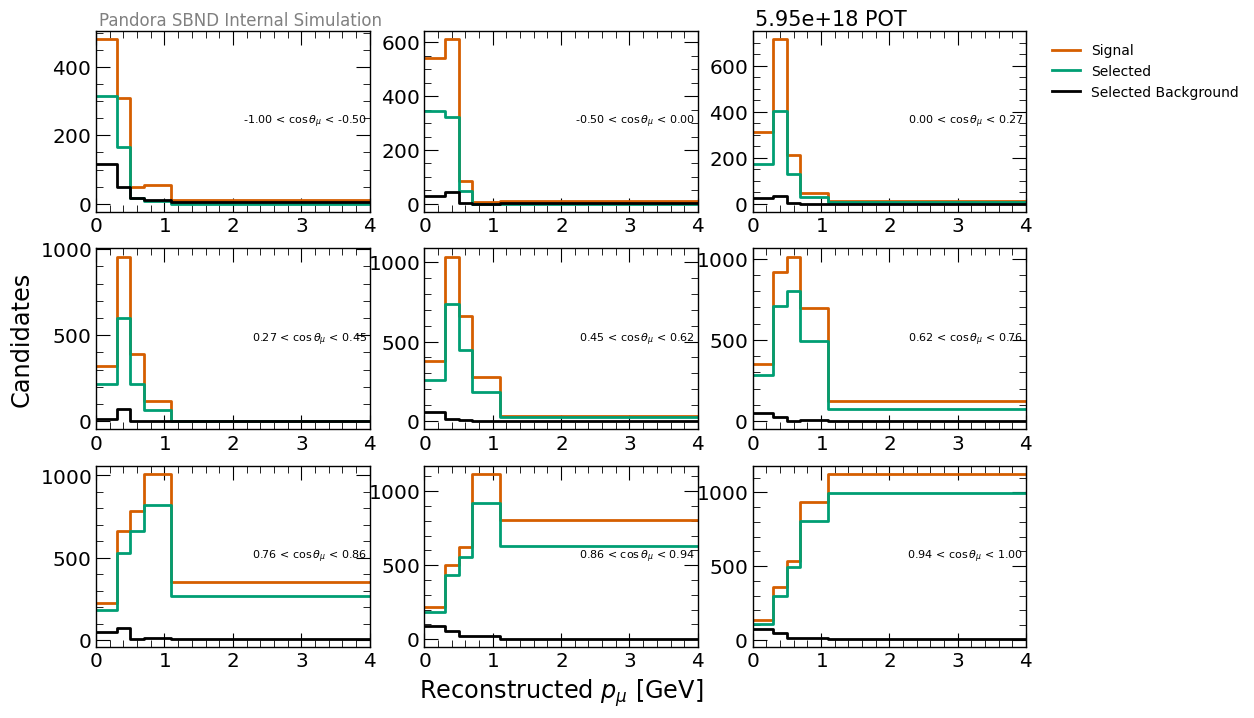

In [114]:
fig,axs = binning2d.plot_differential_hist(reco_sig_momentum,reco_sig_costheta_bin,diff_momentum_bins,genweights_sig,diff_dicts=differential_dicts,
  label='Signal')
fig,axs = binning2d.plot_differential_hist(reco_sel_momentum,reco_sel_costheta_bin,diff_momentum_bins,genweights_sel,diff_dicts=differential_dicts,
  label='Selected',fig=fig,axs=axs)
fig,axs = binning2d.plot_differential_hist(reco_sel_background_momentum,reco_sel_background_costheta_bin,diff_momentum_bins,genweights_sel_background,diff_dicts=differential_dicts,
  label='Selected Background',fig=fig,axs=axs,xlabel=r'Reconstructed $p_{\mu}$ [GeV]',ylabel='Candidates',legend=True,add_labels=True)
plotters.add_label(axs[0,0],PANDORA_QUALIFIER_INTERNAL_LABEL,where=(0.01,1.03+label_y_shift),fontsize=12,color='gray')
plotters.add_label(axs[0,2],POT_LABEL,where=(0.01,1.03+label_y_shift),color='black',alpha=1.,fontsize=15)
plotters.save_plot('reco_2d_costheta_momentum_signal_selected_background',fig=fig,folder_name=f'{PLOT_DIR}/pandora')

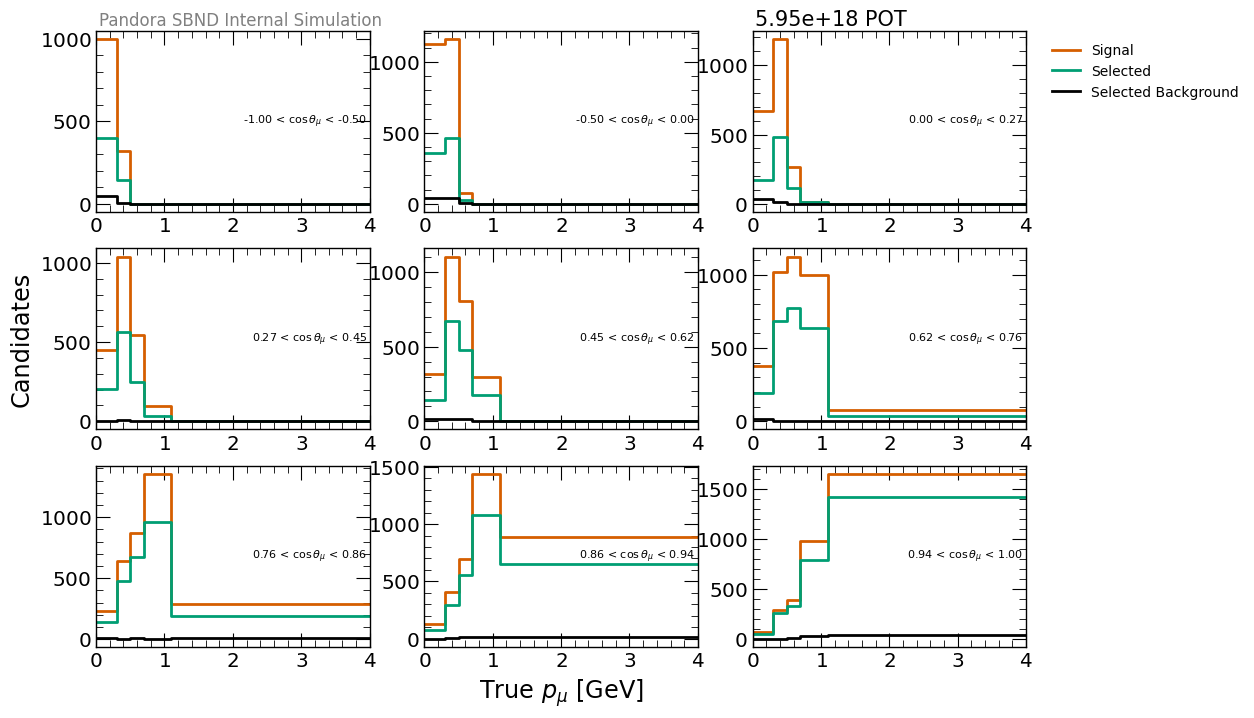

In [115]:
fig,axs = binning2d.plot_differential_hist(true_sig_momentum,true_sig_costheta_bin,diff_momentum_bins,genweights_sig,diff_dicts=differential_dicts,
  label='Signal')
fig,axs = binning2d.plot_differential_hist(true_sel_momentum,true_sel_costheta_bin,diff_momentum_bins,genweights_sel,diff_dicts=differential_dicts,
  label='Selected',fig=fig,axs=axs)
fig,axs = binning2d.plot_differential_hist(true_sel_background_momentum,true_sel_background_costheta_bin,diff_momentum_bins,genweights_sel_background,diff_dicts=differential_dicts,
  label='Selected Background',fig=fig,axs=axs,xlabel=r'True $p_{\mu}$ [GeV]',ylabel='Candidates',legend=True,add_labels=True)
plotters.add_label(axs[0,0],PANDORA_QUALIFIER_INTERNAL_LABEL,where=(0.01,1.03+label_y_shift),fontsize=12,color='gray')
plotters.add_label(axs[0,2],POT_LABEL,where=(0.01,1.03+label_y_shift),color='black',alpha=1.,fontsize=15)
plotters.save_plot('true_2d_costheta_momentum_signal_selected_background',fig=fig,folder_name=f'{PLOT_DIR}/pandora')

/tmp/ipykernel_268318/50528121.py:5: RuntimeWarning: invalid value encountered in divide
  slc_differential_eff = slc_differential_sel/slc_differential_sig


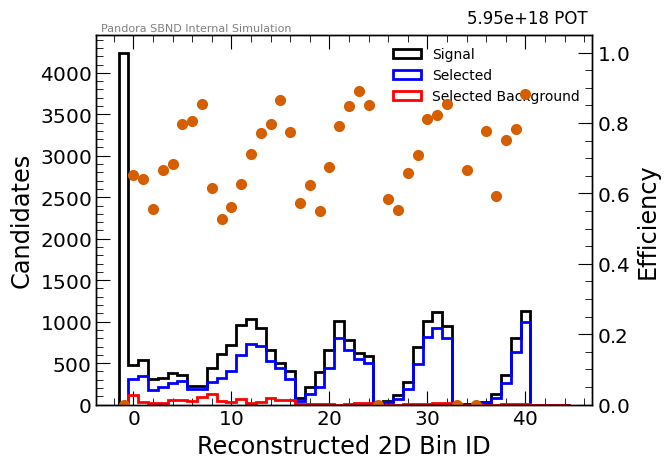

In [116]:
fig,ax = plt.subplots()
slc_differential_sig,_,_ = ax.hist(reco_sig_differential,bins=differential_edges,weights=genweights_sig,label='Signal',histtype='step',color='black',alpha=1.)
slc_differential_sel,_,_ = ax.hist(reco_sel_differential,bins=differential_edges,weights=genweights_sel,label='Selected',histtype='step',color='blue',alpha=1.)
slc_differential_sel_background,_,_ = ax.hist(reco_sel_background_differential,bins=differential_edges,weights=genweights_sel_background,label='Selected Background',histtype='step',color='red',alpha=1.)
slc_differential_eff = slc_differential_sel/slc_differential_sig
assert np.nanmax(slc_differential_eff) <= 1.0, f'Efficiency is greater than 100%: {np.nanmax(slc_differential_eff)}'
ax2 = ax.twinx()
ax2.scatter(differential_centers,slc_differential_eff,label='Efficiency')
#ax2.errorbar(differential_centers,slc_differential_eff,yerr=1/np.sqrt(slc_differential_sel),label='Efficiency',fmt='o')
ax.set_xlabel(r'Reconstructed 2D Bin ID')
ax.set_ylabel('Candidates')
ax2.set_ylim(0,1.05)
ax2.set_ylabel('Efficiency')

plotters.add_label(ax,PANDORA_QUALIFIER_INTERNAL_LABEL,where=(0.01,1.01+label_y_shift),fontsize=8,color='gray')
plotters.add_label(ax,POT_LABEL,where='toprightoutside',color='black',alpha=1.,fontsize=12)
ax.legend()

plotters.save_plot('reco_differential_sel_signal_eff',fig=fig,folder_name=f'{PLOT_DIR}/pandora')

/tmp/ipykernel_268318/3868280209.py:5: RuntimeWarning: invalid value encountered in divide
  slc_differential_eff_truth = slc_differential_sel_truth/slc_differential_sig_truth


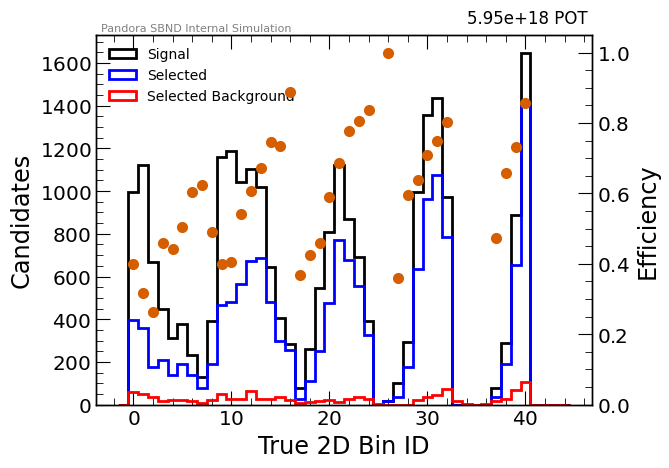

In [117]:
fig,ax = plt.subplots()
slc_differential_sig_truth,_,_ = ax.hist(true_sig_differential,bins=differential_edges,weights=genweights_sig,label='Signal',histtype='step',color='black',alpha=1.)
slc_differential_sel_truth,_,_ = ax.hist(true_sel_differential,bins=differential_edges,weights=genweights_sel,label='Selected',histtype='step',color='blue',alpha=1.)
slc_differential_sel_background_truth,_,_ = ax.hist(true_sel_background_differential,bins=differential_edges,weights=genweights_sel_background,label='Selected Background',histtype='step',color='red',alpha=1.)
slc_differential_eff_truth = slc_differential_sel_truth/slc_differential_sig_truth
assert np.nanmax(slc_differential_eff) <= 1.0, f'Efficiency is greater than 100%: {np.nanmax(slc_differential_eff)}'
ax2 = ax.twinx()
ax2.scatter(differential_centers,slc_differential_eff_truth,label='Efficiency')
#ax2.errorbar(differential_centers,slc_differential_eff_truth,yerr=1/np.sqrt(slc_differential_sel_truth),label='Efficiency',fmt='o')
ax.set_xlabel(r'True 2D Bin ID')
ax.set_ylabel('Candidates')
ax2.set_ylim(0,1.05)
ax2.set_ylabel('Efficiency')

plotters.add_label(ax,PANDORA_QUALIFIER_INTERNAL_LABEL,where=(0.01,1.01+label_y_shift),fontsize=8,color='gray')
plotters.add_label(ax,POT_LABEL,where='toprightoutside',color='black',alpha=1.,fontsize=12)
ax.legend()

plotters.save_plot('truth_differential_sel_signal_eff',fig=fig,folder_name=f'{PLOT_DIR}/pandora')

### 2.2 Smearing matrix

In [118]:
from unfolding_inputs import get_smear_matrix

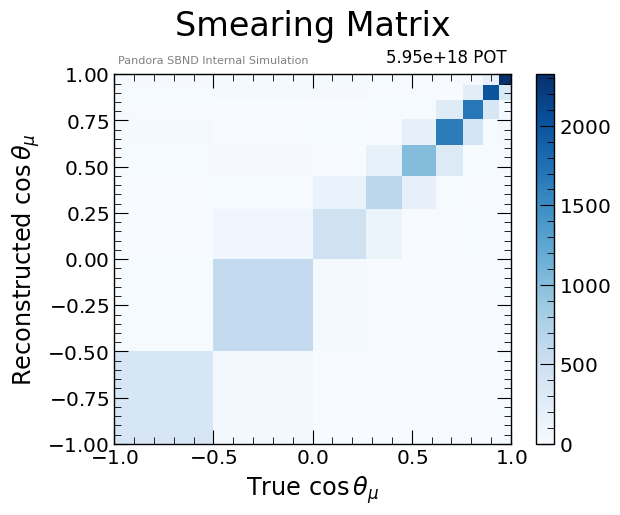

In [119]:
#True vs reco costheta
slc_costheta_smearing = get_smear_matrix(true_sel_costheta,reco_sel_costheta,costheta_bins,weights=genweights_sel)
costheta_eff = get_eff(slc_costheta_smearing, slc_costheta_sig_truth)

fig,ax = plt.subplots()
im = ax.pcolormesh(costheta_bins,costheta_bins,slc_costheta_smearing.T,cmap='Blues')
ax.set_xlabel(r'True $\cos\theta_{\mu}$')
ax.set_ylabel(r'Reconstructed $\cos\theta_{\mu}$')
ax.set_title('Smearing Matrix')
fig.colorbar(im,ax=ax)
plotters.add_label(ax,PANDORA_QUALIFIER_INTERNAL_LABEL,where=(0.01,1.03+label_y_shift),fontsize=8,color='gray')
plotters.add_label(ax,POT_LABEL,where='toprightoutside',color='black',alpha=1.,fontsize=12)
plotters.save_plot('costheta_smearing_matrix',fig=fig,folder_name=f'{PLOT_DIR}/pandora')

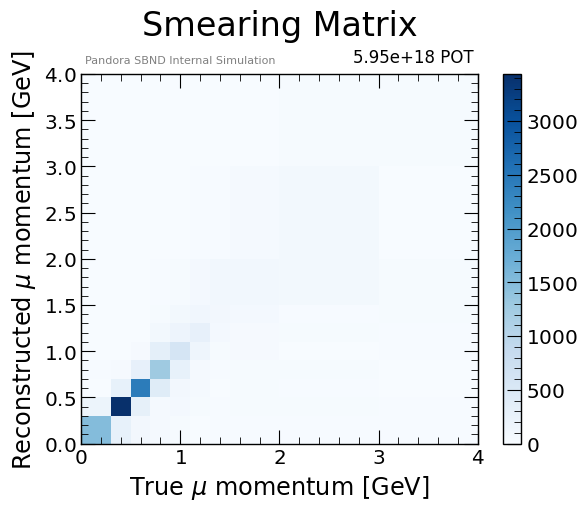

In [120]:
#True vs reco momentum
slc_momentum_smearing = get_smear_matrix(true_sel_momentum,reco_sel_momentum,momentum_bins,weights=genweights_sel)
momentum_eff = get_eff(slc_momentum_smearing, slc_momentum_sig_truth)

fig,ax = plt.subplots()
im = ax.pcolormesh(momentum_bins,momentum_bins,slc_momentum_smearing.T,cmap='Blues')
ax.set_xlabel(r'True $\mu$ momentum [GeV]')
ax.set_ylabel(r'Reconstructed $\mu$ momentum [GeV]')
ax.set_xlim(0,4.)
ax.set_ylim(0,4.)
ax.set_title('Smearing Matrix')
fig.colorbar(im,ax=ax)
plotters.add_label(ax,PANDORA_QUALIFIER_INTERNAL_LABEL,where=(0.01,1.03+label_y_shift),fontsize=8,color='gray')
plotters.add_label(ax,POT_LABEL,where='toprightoutside',color='black',alpha=1.,fontsize=12)
plotters.save_plot('momentum_smearing_matrix',fig=fig,folder_name=f'{PLOT_DIR}/pandora')


/exp/sbnd/app/users/brindenc/develop/cafpyana/analysis_village/unfolding/unfolding_inputs.py:79: RuntimeWarning: invalid value encountered in divide
  eff = reco_vs_true.T.sum(axis=0) / true_signal  # efficiency per truth bin


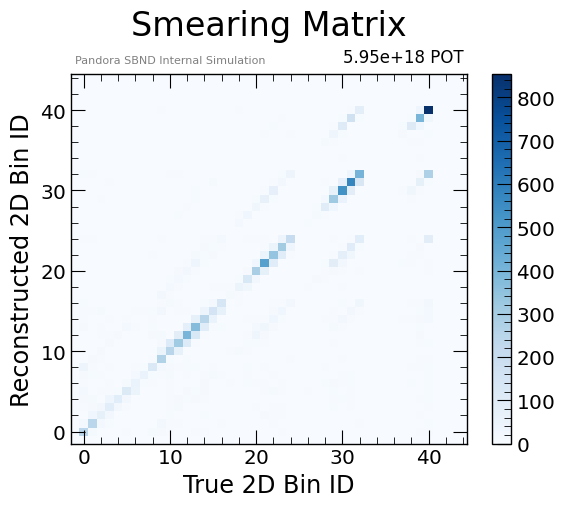

In [121]:
#True vs reco differential
slc_differential_smearing = get_smear_matrix(true_sel_differential,reco_sel_differential,differential_edges,weights=genweights_sel)
differential_eff = get_eff(slc_differential_smearing, slc_differential_sig_truth)

fig,ax = plt.subplots()
im = ax.pcolormesh(differential_edges,differential_edges,slc_differential_smearing.T,cmap='Blues')
ax.set_xlabel(r'True 2D Bin ID')
ax.set_ylabel(r'Reconstructed 2D Bin ID')
ax.set_title('Smearing Matrix')
# ax.set_xlim(-2,10)
# ax.set_ylim(-2,10)
fig.colorbar(im,ax=ax)
plotters.add_label(ax,PANDORA_QUALIFIER_INTERNAL_LABEL,where=(0.01,1.03+label_y_shift),fontsize=8,color='gray')
plotters.add_label(ax,POT_LABEL,where='toprightoutside',color='black',alpha=1.,fontsize=12)
plotters.save_plot('differential_smearing_matrix',fig=fig,folder_name=f'{PLOT_DIR}/pandora')


### 2.3 Response matrix

In [122]:
from sbnd.stats import stats

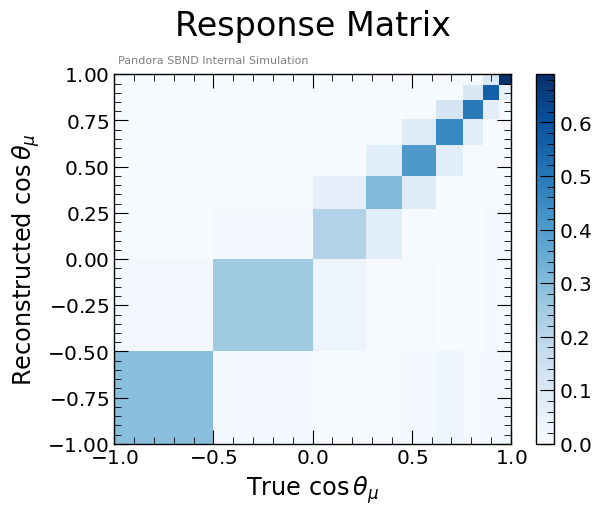

In [123]:
slc_costheta_response = stats.convert_smearing_to_response(slc_costheta_smearing,slc_costheta_eff_truth)

fig,ax = plt.subplots()
im = ax.pcolormesh(costheta_bins,costheta_bins,slc_costheta_response.T,cmap='Blues')
fig.colorbar(im,ax=ax)
ax.set_xlabel(r'True $\cos\theta_{\mu}$')
ax.set_ylabel(r'Reconstructed $\cos\theta_{\mu}$')
ax.set_title('Response Matrix')

plotters.add_label(ax,PANDORA_QUALIFIER_INTERNAL_LABEL,where=(0.01,1.03+label_y_shift),fontsize=8,color='gray')
#plotters.add_label(ax,POT_LABEL,where='toprightoutside',color='black',alpha=1.,fontsize=12)
plotters.save_plot('costheta_response_matrix',fig=fig,folder_name=f'{PLOT_DIR}/pandora')

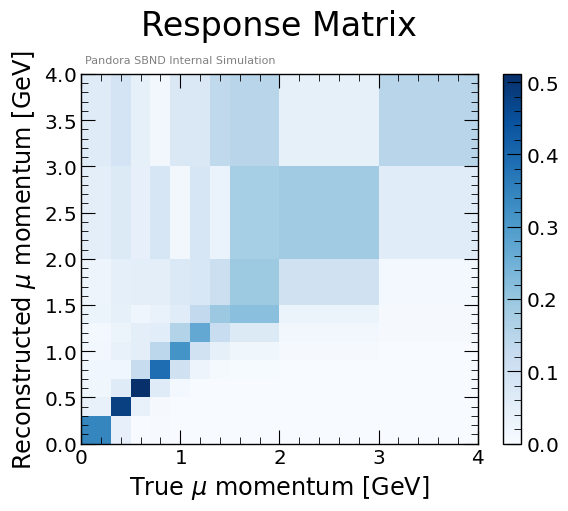

In [124]:
#Response vs reco momentum
slc_momentum_response = stats.convert_smearing_to_response(slc_momentum_smearing,slc_momentum_eff_truth)

fig,ax = plt.subplots()
im = ax.pcolormesh(momentum_bins,momentum_bins,slc_momentum_response.T,cmap='Blues')
ax.set_xlabel(r'True $\mu$ momentum [GeV]')
ax.set_ylabel(r'Reconstructed $\mu$ momentum [GeV]')
ax.set_title('Response Matrix')
ax.set_xlim(0,4.)
ax.set_ylim(0,4.)
fig.colorbar(im,ax=ax)
plotters.add_label(ax,PANDORA_QUALIFIER_INTERNAL_LABEL,where=(0.01,1.03+label_y_shift),fontsize=8,color='gray')
#plotters.add_label(ax,POT_LABEL,where='toprightoutside',color='black',alpha=1.,fontsize=12)
plotters.save_plot('momentum_response_matrix',fig=fig,folder_name=f'{PLOT_DIR}/pandora')

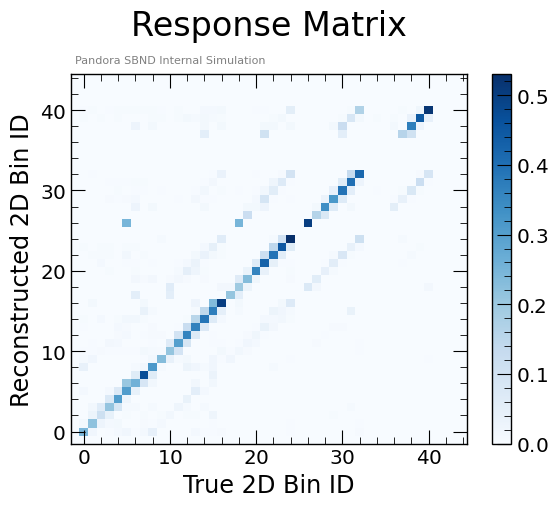

In [125]:
#Response for differential
slc_differential_response = stats.convert_smearing_to_response(slc_differential_smearing,slc_differential_eff_truth)

fig,ax = plt.subplots()
im = ax.pcolormesh(differential_edges,differential_edges,slc_differential_response.T,cmap='Blues')
ax.set_xlabel(r'True 2D Bin ID')
ax.set_ylabel(r'Reconstructed 2D Bin ID')
ax.set_title('Response Matrix')
fig.colorbar(im,ax=ax)
plotters.add_label(ax,PANDORA_QUALIFIER_INTERNAL_LABEL,where=(0.01,1.03+label_y_shift),fontsize=8,color='gray')
#plotters.add_label(ax,POT_LABEL,where='toprightoutside',color='black',alpha=1.,fontsize=12)
plotters.save_plot('differential_response_matrix',fig=fig,folder_name=f'{PLOT_DIR}/pandora')

## 3. Flux

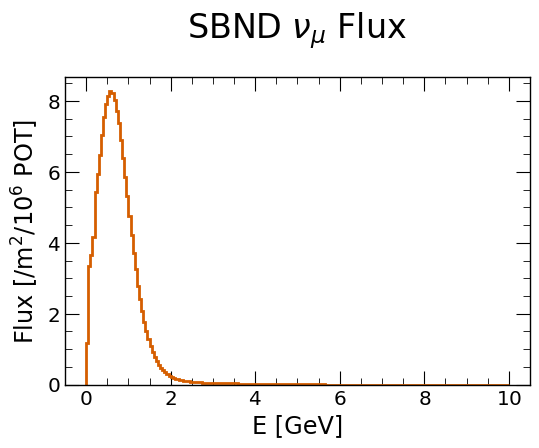

In [126]:
fig,ax = plt.subplots(figsize=(6,4))
ax.hist(bin_edges[:-1], bins=bin_edges, weights=flux_vals, histtype="step")
ax.set_xlabel("E [GeV]")
ax.set_ylabel("Flux [/m$^{2}$/10$^{6}$ POT]")
ax.set_title("SBND $\\nu_\\mu$ Flux")
fig.savefig(f'{PLOT_DIR}/flux.png')
plt.show()

## 4. $\tilde{\sigma}$ for CV

In [127]:
#Compute sigma_tilde
slc_costheta_sigma_tilde = XSEC_UNIT*(slc_costheta_response @ slc_costheta_sel_truth + slc_costheta_sel_background)
slc_momentum_sigma_tilde = XSEC_UNIT*(slc_momentum_response @ slc_momentum_sel_truth + slc_momentum_sel_background)
slc_differential_sigma_tilde = XSEC_UNIT*(slc_differential_response @ slc_differential_sel_truth + slc_differential_sel_background)

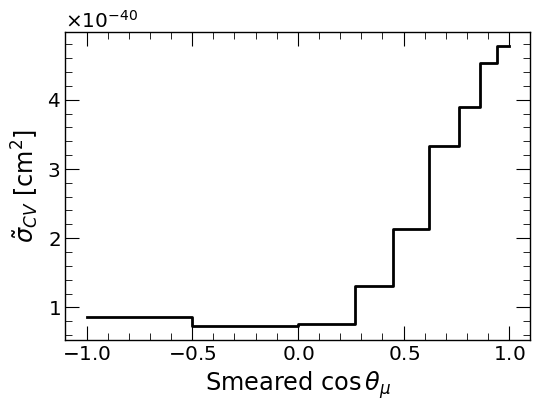

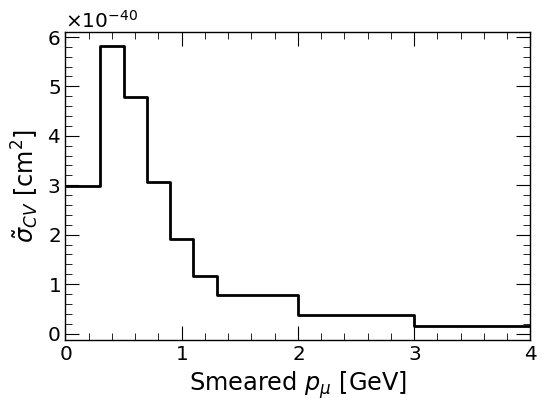

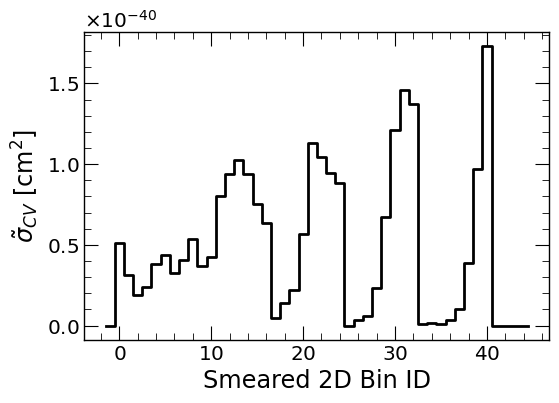

In [128]:
from sbnd.plotlibrary import makeplot
fig,ax = plt.subplots(figsize=(6,4))
makeplot.plot_hist_edges(costheta_bins,slc_costheta_sigma_tilde,None,ax=ax,color='black',label='Signal',alpha=1.)
ax.set_ylabel(r'$\tilde{\sigma}_{CV}$ [cm$^{2}$]')
ax.set_xlabel(r'Smeared $\cos\theta_{\mu}$')
plt.show()

fig,ax = plt.subplots(figsize=(6,4))
makeplot.plot_hist_edges(momentum_bins,slc_momentum_sigma_tilde,None,ax=ax,color='black',label='Signal',alpha=1.)
ax.set_ylabel(r'$\tilde{\sigma}_{CV}$ [cm$^{2}$]')
ax.set_xlabel(r'Smeared $p_{\mu}$ [GeV]')
ax.set_xlim(0,4.)
plt.show()

fig,ax = plt.subplots(figsize=(6,4))
makeplot.plot_hist_edges(differential_edges,slc_differential_sigma_tilde,None,ax=ax,color='black',label='Signal',alpha=1.)
ax.set_ylabel(r'$\tilde{\sigma}_{CV}$ [cm$^{2}$]')
ax.set_xlabel(r'Smeared 2D Bin ID')
plt.show()

## 5. Systematics

### 5.1 Make systematics

#### 5.1.1 Get slim systematics sorted out

In [129]:
#Get masks
sig_mask = np.isin(slc_mc_slim.data.truth.event_type,[0,1])
bkg_mask = ~sig_mask
slc_mc_slim.cut_all(cut=False) #TEMPORARY
cut_col = slc_mc_slim.get_key('cut.all')[0]
sel_mask = slc_mc_slim.data[cut_col] & (slc_mc_slim.data.has_muon == True)

slc_mc_slim_signal = CAFSlice(slc_mc_slim.data[sig_mask])
slc_mc_slim_background = CAFSlice(slc_mc_slim.data[sel_mask&bkg_mask])
slc_mc_slim_sel = CAFSlice(slc_mc_slim.data[sel_mask&sig_mask])

#### 5.1.2 Process

In [130]:
#Add the stat weights TEMPRORARY
slc_mc_sel_signal.add_stat_unc()
slc_mc_sel_background.add_stat_unc()

slc_mc_slim_signal.add_stat_unc()
slc_mc_slim_background.add_stat_unc()
slc_mc_slim_sel.add_stat_unc()


Generating event seeds: 100%|██████████| 3762/3762 [00:00<00:00, 111510.59it/s]


Successfully generated 3762 unique seeds


Generating event seeds: 100%|██████████| 285/285 [00:00<00:00, 106806.35it/s]


Successfully generated 285 unique seeds


Generating event seeds: 100%|██████████| 6250/6250 [00:00<00:00, 111527.38it/s]


...

Generating event seeds: 100%|██████████| 286/286 [00:00<00:00, 105503.16it/s]


Successfully generated 286 unique seeds


Generating event seeds: 100%|██████████| 3766/3766 [00:00<00:00, 112071.10it/s]


Successfully generated 3766 unique seeds


Generating universes: 100%|██████████| 100/100 [00:01<00:00, 79.84it/s]


In [131]:
from sbnd.cafclasses.systematics import Systematics
%load_ext autoreload
%autoreload 2

csystematics = Systematics('costheta', costheta_bins,
  reco_sel_costheta, reco_sel_background_costheta, genweights_sig, genweights_sel, genweights_sel_background,
  xsec_unit=XSEC_UNIT,
  true_sig=true_sig_costheta,
  true_sel=true_sel_costheta,
  true_sel_background=true_sel_background_costheta,
  keys=slc_mc_sel.data.truth.keys(),
  pattern=['GENIE','Flux','stat'])

msystematics = Systematics('momentum', momentum_bins,
  reco_sel_momentum, reco_sel_background_momentum, genweights_sig, genweights_sel, genweights_sel_background,
  xsec_unit=XSEC_UNIT,
  true_sig=true_sig_momentum,
  true_sel=true_sel_momentum,
  true_sel_background=true_sel_background_momentum,
  keys=slc_mc_sel.data.truth.keys(),
  pattern=['GENIE','Flux','stat'])

dsystematics = Systematics('differential', differential_edges,
  reco_sel_differential, reco_sel_background_differential, genweights_sig, genweights_sel, genweights_sel_background,
  xsec_unit=XSEC_UNIT,
  true_sig=true_sig_differential,
  true_sel=true_sel_differential,
  true_sel_background=true_sel_background_differential,
  keys=slc_mc_sel.data.truth.keys(),
  pattern=['GENIE','Flux','stat'])

# csystematics = Systematics('costheta', costheta_bins, XSEC_UNIT,
#   true_sig_costheta, true_sel_costheta, true_sel_background_costheta, reco_sel_costheta,
#   reco_sel_background_costheta, genweights_sig, genweights_sel, genweights_sel_background,
#   keys=slc_mc_sel.data.truth.keys())

# msystematics = Systematics('momentum', momentum_bins, XSEC_UNIT,
#   true_sig_momentum, true_sel_momentum, true_sel_background_momentum, reco_sel_momentum,
#   reco_sel_background_momentum, genweights_sig, genweights_sel, genweights_sel_background,
#   keys=slc_mc_sel.data.truth.keys())

# dsystematics = Systematics('differential', differential_edges, XSEC_UNIT,
#   true_sig_differential, true_sel_differential, true_sel_background_differential, reco_sel_differential,
#   reco_sel_background_differential, genweights_sig, genweights_sel, genweights_sel_background,
#   keys=slc_mc_sel.data.truth.keys())

#csystematics_slim = Systematics('costheta_slim', costheta_bins, XSEC_UNIT,
  

# systematics = Systematics(slc_mc_sel_signal.data.truth.keys(),costheta_bins, momentum_bins, differential_edges,
#                  slc_costheta_sigma_tilde, slc_momentum_sigma_tilde, slc_differential_sigma_tilde,
#                  slc_costheta_sel, slc_momentum_sel, slc_differential_sel,
#                  slc_costheta_sel_background, slc_momentum_sel_background, slc_differential_sel_background,
#                  slc_costheta_sel_truth, slc_momentum_sel_truth, slc_differential_sel_truth,
#                  slc_costheta_response, slc_momentum_response, slc_differential_response,
#                  slc_costheta_eff_truth, slc_momentum_eff_truth, slc_differential_eff_truth,
#                  XSEC_UNIT)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


/exp/sbnd/app/users/brindenc/develop/cafpyana/analysis_village/numuincl/sbnd/stats/stats.py:179: RuntimeWarning: invalid value encountered in divide
  eff_truth = sel_truth / sig_truth
/exp/sbnd/app/users/brindenc/develop/cafpyana/analysis_village/numuincl/sbnd/cafclasses/systematics.py:187: RuntimeWarning: divide by zero encountered in divide
  # Handle division by zero
/exp/sbnd/app/users/brindenc/develop/cafpyana/analysis_village/numuincl/sbnd/cafclasses/systematics.py:187: RuntimeWarning: invalid value encountered in divide
  # Handle division by zero


In [171]:
for s in [csystematics,msystematics,dsystematics]:
  s.process_systematics(slc_mc_signal.data, slc_mc_sel_signal.data)
  s.compute_covariances()
  s.combine_summaries(summary_keys=['total','flux','xsec'])

KeyboardInterrupt: 

In [ ]:
len(csystematics.systematics.keys())

63

In [ ]:
# Event rate unc. < xsec unc.
stats.get_total_unc(slc_costheta_sel+slc_costheta_sel_background,csystematics.systematics['expskin_Flux']['event_fracunc'])*100,stats.get_total_unc(slc_costheta_sigma_tilde,csystematics.systematics['expskin_Flux']['xsec_fracunc'])*100

(3.4821723333395447, 0.24769349796056828)

In [139]:
#Save the systematics
for s in [csystematics,msystematics,dsystematics]:
  s.save(save_dir=f'{BASE_DIR}/data/{day}/syst')

Saving 19 keys to /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/data/2026_01_18/syst
Saving 19 keys to /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/data/2026_01_18/syst
Saving 19 keys to /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/data/2026_01_18/syst


### 5.2 Load systematics

#### 5.2.1. Merge full syst with det syst

In [ ]:
from sbnd.cafclasses.systematics import Systematics
csystematics_rw = Systematics.from_saved(f'{BASE_DIR}/data/{day}/syst',var_name='costheta',ignore_keys=['total'],select_types=['xsec','flux','stat'])
msystematics_rw = Systematics.from_saved(f'{BASE_DIR}/data/{day}/syst',var_name='momentum',ignore_keys=['total'],select_types=['xsec','flux','stat'])
dsystematics_rw = Systematics.from_saved(f'{BASE_DIR}/data/{day}/syst',var_name='differential',ignore_keys=['total'],select_types=['xsec','flux','stat'])

csystematics_det = Systematics.from_saved(f'{BASE_DIR}/data/2026_01_18/syst/lowz',var_name='costheta',metadata_dir='metadata_detsys',ignore_keys=['total'])
msystematics_det = Systematics.from_saved(f'{BASE_DIR}/data/2026_01_18/syst/lowz',var_name='momentum',metadata_dir='metadata_detsys',ignore_keys=['total'])
dsystematics_det = Systematics.from_saved(f'{BASE_DIR}/data/2026_01_18/syst/lowz',var_name='differential',metadata_dir='metadata_detsys',ignore_keys=['total'])

Loading systematics: 100%|██████████| 70/70 [01:15<00:00,  1.08s/ subfolder]


Loaded 62 systematics from /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/data/2026_01_18/syst


Loading systematics: 100%|██████████| 70/70 [01:15<00:00,  1.07s/ subfolder]


Loaded 62 systematics from /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/data/2026_01_18/syst


Loading systematics: 100%|██████████| 70/70 [01:16<00:00,  1.09s/ subfolder]


...

Loaded 20 systematics from /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/data/2026_01_18/syst/lowz


Loading systematics: 100%|██████████| 21/21 [00:17<00:00,  1.19 subfolder/s]


Loaded 20 systematics from /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/data/2026_01_18/syst/lowz


Loading systematics: 100%|██████████| 21/21 [00:18<00:00,  1.17 subfolder/s]

Loaded 20 systematics from /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/data/2026_01_18/syst/lowz


In [ ]:
for s,s_det in zip([csystematics_rw,msystematics_rw,dsystematics_rw],[csystematics_det,msystematics_det,dsystematics_det]):
  s.combine(s_det)
  #Add flat systematics
  s.process_flat_systematic('pot',0.02)
  s.process_flat_systematic('nt',0.01)
  s.compute_covariances(['pot','nt'])
  #Combine to overall systematics
  s.combine_summaries(summary_keys=['total','flux','xsec'])
  s.save(save_dir=f'{BASE_DIR}/data/{day}/syst')

Saving 19 keys to /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/data/2026_01_18/syst
Saving 19 keys to /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/data/2026_01_18/syst


/exp/sbnd/app/users/brindenc/develop/cafpyana/analysis_village/numuincl/sbnd/stats/stats.py:35: RuntimeWarning: invalid value encountered in divide
  diff_fractional = diff / denom
/exp/sbnd/app/users/brindenc/develop/cafpyana/analysis_village/numuincl/sbnd/stats/stats.py:75: RuntimeWarning: invalid value encountered in scalar divide
  correlation[i,j] = covariance_matrix[i,j] / (stds[i] * stds[j])
/exp/sbnd/app/users/brindenc/develop/cafpyana/analysis_village/numuincl/sbnd/stats/stats.py:62: RuntimeWarning: invalid value encountered in divide
  fractional_uncertainty = stds / cv
/exp/sbnd/app/users/brindenc/develop/cafpyana/analysis_village/numuincl/sbnd/stats/stats.py:63: RuntimeWarning: invalid value encountered in divide
  biases = np.mean(diff, axis=0) / cv
/exp/sbnd/app/users/brindenc/develop/cafpyana/analysis_village/numuincl/sbnd/cafclasses/systematics.py:834: RuntimeWarning: overflow encountered in add
  self.systematics[sk]['event_fraccov'] += sys_dict['event_fraccov']
/exp/s

Saving 19 keys to /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/data/2026_01_18/syst


#### 5.2.2. Just load it

In [53]:
csystematics_rw = Systematics.from_saved(f'{BASE_DIR}/data/2026_01_28/syst/lowz',var_name='costheta',metadata_dir='metadata_detsys')
msystematics_rw = Systematics.from_saved(f'{BASE_DIR}/data/2026_01_28/syst/lowz',var_name='momentum',metadata_dir='metadata_detsys')
dsystematics_rw = Systematics.from_saved(f'{BASE_DIR}/data/2026_01_28/syst/lowz',var_name='differential',metadata_dir='metadata_detsys')

Loading systematics: 100%|██████████| 32/32 [00:00<00:00, 155.50 subfolder/s]


Loaded 32 systematics from /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/data/2026_01_28/syst/lowz


Loading systematics:  50%|█████     | 16/32 [00:00<00:00, 159.16 subfolder/s]

Loading systematics: 100%|██████████| 32/32 [00:00<00:00, 164.55 subfolder/s]


Loaded 32 systematics from /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/data/2026_01_28/syst/lowz


Loading systematics: 100%|██████████| 32/32 [00:00<00:00, 99.44 subfolder/s] 

Loaded 32 systematics from /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/data/2026_01_28/syst/lowz


In [49]:
costheta_data,_ = np.histogram(slc_data.data.mu.pfp.trk.costheta,bins=COSTHETA_BINS)
momentum_data,_ = np.histogram(slc_data.data.mu.pfp.trk.P.p_muon,bins=MOMENTUM_BINS)
differential_data,_ = np.histogram(slc_data.data.bin.costheta,bins=DIFFERENTIAL_EDGES)

In [54]:
(msystematics_rw.systematics['total']['event_fracunc'] * (msystematics_rw.sel+msystematics_rw.sel_background))**2

array([114559.25169719, 417831.2615943 , 254012.48248511, 121681.98516581,
        62530.93417183,  20591.46515236,   7212.56230125,   7375.38499257,
         2372.89652732,   1233.71733916])

In [55]:
np.diag(msystematics_rw.systematics['total']['event_cov'])

array([114559.25169719, 417831.2615943 , 254012.48248511, 121681.98516581,
        62530.93417183,  20591.46515236,   7212.56230125,   7375.38499257,
         2372.89652732,   1233.71733916])

In [57]:
msystematics_rw.sel+msystematics_rw.sel_background,momentum_data

(array([1484.17706854, 2915.11880039, 2293.0191542 , 1475.31891559,
         804.04865139,  424.39418497,  240.0440426 ,  254.12443108,
         113.77027417,   61.19946546]),
 array([3331, 6746, 5250, 2974, 1454,  670,  265,  274,   94,    9]))

In [58]:
from sbnd.stats.stats import calc_chi2

In [ ]:
calc_chi2()

In [27]:
csystematics_nocut_rw = Systematics.from_saved(f'{BASE_DIR}/data/2026_01_28/syst/precut',var_name='costheta',metadata_dir='metadata_detsys')
msystematics_nocut_rw = Systematics.from_saved(f'{BASE_DIR}/data/2026_01_28/syst/precut',var_name='momentum',metadata_dir='metadata_detsys')
dsystematics_nocut_rw = Systematics.from_saved(f'{BASE_DIR}/data/2026_01_28/syst/precut',var_name='differential',metadata_dir='metadata_detsys')

Loading systematics:   0%|          | 0/32 [00:00<?, ? subfolder/s]

Loading systematics: 100%|██████████| 32/32 [00:00<00:00, 548.68 subfolder/s]


Loaded 32 systematics from /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/data/2026_01_28/syst/precut


Loading systematics: 100%|██████████| 32/32 [00:00<00:00, 554.12 subfolder/s]


Loaded 32 systematics from /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/data/2026_01_28/syst/precut


Loading systematics: 100%|██████████| 32/32 [00:01<00:00, 21.10 subfolder/s]

Loaded 32 systematics from /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/data/2026_01_28/syst/precut


In [30]:
(msystematics_nocut_rw.systematics['total']['event_fracunc'] * (msystematics_nocut_rw.sel+msystematics_nocut_rw.sel_background))**2

array([ 2913110.63229588, 14837947.95019795, 10229789.73668075,
        4351819.61026453,  1009021.10766558,   810800.6795951 ,
         186061.85677862,   689374.38292063,   881093.15578422,
        2511890.04951081])

In [31]:
np.diag(msystematics_nocut_rw.systematics['total']['event_cov'])

array([ 2913110.63229588, 14837947.95019794, 10229789.73668075,
        4351819.61026453,  1009021.10766558,   810800.6795951 ,
         186061.85677862,   689374.38292062,   881093.15578422,
        2511890.04951081])

## 6. Selection with uncertainties

### 6.1 Event counts

In [174]:
# Break data into lists of objects
slcs = []

#Get event type col
slc_event_type_col = slc_mc_sel.get_key('truth.event_type')

# Group data by event type once
slc_groups = slc_mc_sel.data.groupby(slc_event_type_col)

# Create objects only for groups that exist
for key, val in EVENT_TYPE_LIST.items():
    if key in slc_groups.groups:
        slcs.append(CAFSlice(slc_groups.get_group(key)))

/tmp/ipykernel_268318/4046892220.py:13: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  slcs.append(CAFSlice(slc_groups.get_group(key)))


In [175]:
#Get label info
labels = []
names = []
colors = []

for key,item in EVENT_TYPE_LIST.items():
    if key == -1: #no unknown for now
        continue
    labels.append(item[0])
    names.append(item[1])
    colors.append(item[2])

slc_weights = [s.data.genweight for s in slcs]

#Assert no nans in weights
assert [any(np.isnan(sw)) for sw in slc_weights].count(True) == 0


In [176]:
_slc_data = slc_data.copy()
_slc_data.cut_all(cut=True)

In [177]:
csystematics.systematics['total']['event_fracunc']

array([0.17776207, 0.18597392, 0.19566921, 0.18061243, 0.18895606,
       0.19354175, 0.18459005, 0.19723124, 0.22584756])

/exp/sbnd/app/users/brindenc/develop/cafpyana/analysis_village/numuincl/sbnd/plotlibrary/makeplot.py:105: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data_counts = data_series.groupby(pd.cut(data_series,bins=bins)).count()


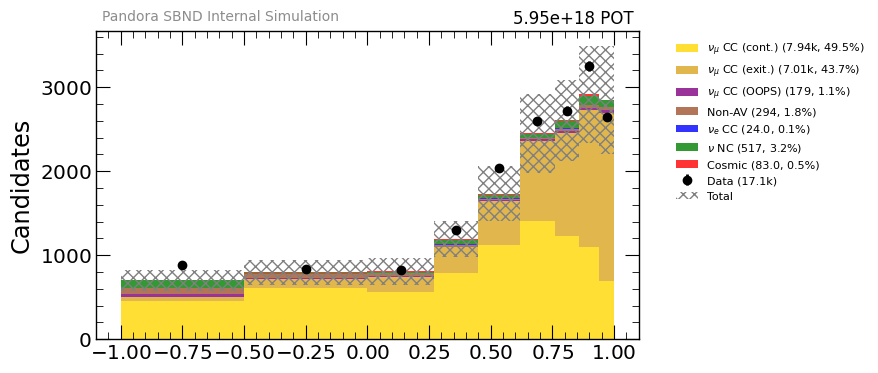

In [178]:
reco_costhetas = [s.data.mu.pfp.trk.costheta for s in slcs]
_costheta_data = _slc_data.data.mu.pfp.trk.costheta
yerr = csystematics.systematics['total']['event_fracunc']
tot_unc = csystematics.systematics['total']['event_totalunc']

from sbnd.plotlibrary.makeplot import create_hist
yerr_label=r'Total'
fig,ax,n_perbin = create_hist(reco_costhetas,labels,bins=costheta_bins,yerr=yerr,yerr_label=yerr_label,data_series=_costheta_data,colors=colors,weights=slc_weights,label=PANDORA_QUALIFIER_INTERNAL_LABEL,return_counts=True,pot_label=POT_LABEL,savename=f'reco_costheta_fluxxsecsyst',plot_dir=f'{PLOT_DIR}/pandora/syst',close=False)

(0.0, 4.0)

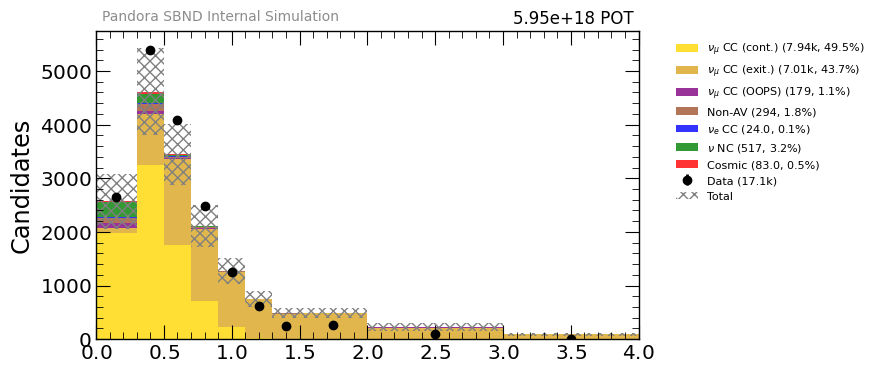

In [179]:
reco_momentums = [s.data.mu.pfp.trk.P.p_muon for s in slcs]
_momentum_data = _slc_data.data.mu.pfp.trk.P.p_muon
yerr = msystematics.systematics['total']['event_fracunc']
tot_unc = msystematics.systematics['total']['event_totalunc']

fig,ax,n_perbin = create_hist(reco_momentums,labels,bins=momentum_bins,yerr=yerr,yerr_label=yerr_label,data_series=_momentum_data,colors=colors,weights=slc_weights,label=PANDORA_QUALIFIER_INTERNAL_LABEL,return_counts=True,pot_label=POT_LABEL,savename=f'reco_momentum_fluxxsecsyst',plot_dir=f'{PLOT_DIR}/pandora/syst',close=False,bin_centers=momentum_centers)
ax.set_xlim(0,4)

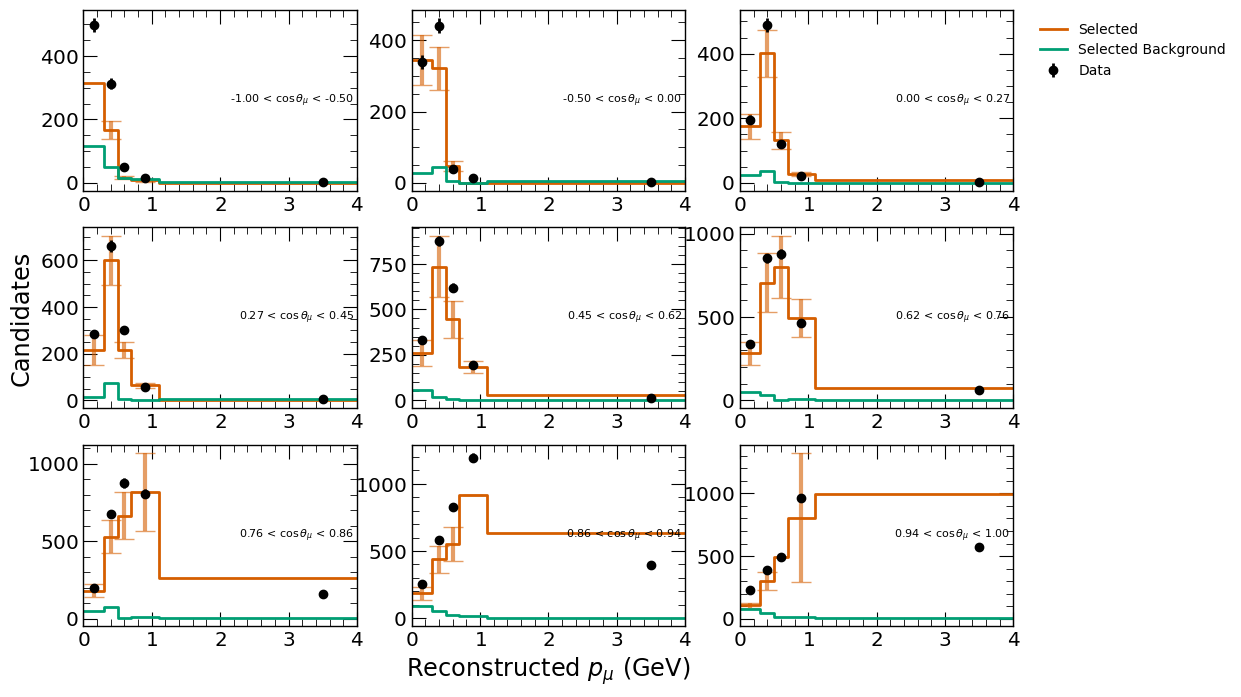

In [ ]:
fig,axs = binning2d.plot_differential_hist(reco_sig_momentum,reco_sig_costheta_bin,diff_momentum_bins,genweights_sig,yerrs=None,label='Signal')
fig,axs = binning2d.plot_differential_hist(reco_sel_momentum,reco_sel_costheta_bin,diff_momentum_bins,genweights_sel,yerrs=dsystematics.systematics['total']['event_fracunc'],label='Selected',frac_unc=True,fig=fig,axs=axs)
fig,axs = binning2d.plot_differential_hist(reco_sel_background_momentum,reco_sel_background_costheta_bin,diff_momentum_bins,genweights_sel_background,yerrs=None,label='Selected Background',fig=fig,axs=axs)
fig,axs = binning2d.plot_differential_scatter(_slc_data.data.mu.pfp.trk.P.p_muon,_slc_data.data.bin.costheta,diff_momentum_bins,fig=fig,axs=axs,legend=True,xlabel=r'Reconstructed $p_{\mu}$ (GeV)',add_labels=True,label='Data',bin_centers=diff_momentum_centers,color='black')
plotters.save_plot('diff_eventcount',fig=fig,folder_name=f'{PLOT_DIR}/pandora/syst')

### 6.2 Uncertainties as function of kinematics

### 6.2.1 No det systematics

In [206]:
summary_keys = ['total','flux','xsec','pds','tpc','sce','nt','pot','pds','tpc','sce','cosmic','calo']
for s,var_name in zip([csystematics_rw,msystematics_rw,dsystematics_rw],['costheta','momentum','differential']):
  for unc_type in ['event','xsec']:
    if var_name == 'differential':
      bins = differential_edges
    elif var_name == 'costheta':
      bins = costheta_bins
    elif var_name == 'momentum':
      bins = momentum_bins
    #All systematics
    fig,ax,im = s.plot_event_rate_errs(unc_type,exclude_keys=summary_keys,sort=True)
    plotters.add_label(ax,PANDORA_QUALIFIER_INTERNAL_LABEL,where=(0.01,1.01+label_y_shift),fontsize=8,color='gray')
    plotters.add_label(ax,POT_LABEL,where='toprightoutside',color='black',alpha=1.,fontsize=12)
    plotters.save_plot(f'{var_name}_{unc_type}_errs_full', fig=fig, folder_name=f'{PLOT_DIR}/syst/fracunc')
    plt.close()

    fig,ax,im = s.plot_event_rate_errs(unc_type,include_keys=summary_keys+['stat'],sort=True)
    plotters.add_label(ax,PANDORA_QUALIFIER_INTERNAL_LABEL,where=(0.01,1.01+label_y_shift),fontsize=8,color='gray')
    plotters.add_label(ax,POT_LABEL,where='toprightoutside',color='black',alpha=1.,fontsize=12)
    plotters.save_plot(f'{var_name}_{unc_type}_errs_summary', fig=fig, folder_name=f'{PLOT_DIR}/syst/fracunc')
    plt.close()
  #   break
  # break


In [182]:
csystematics_rw

Systematics(variable=costheta, keys=['expskin_Flux', 'horncurrent_Flux', 'kminus_Flux', 'kplus_Flux', 'kzero_Flux', 'nucleoninexsec_Flux', 'nucleonqexsec_Flux', 'nucleontotxsec_Flux', 'piminus_Flux', 'pioninexsec_Flux', 'pionqexsec_Flux', 'piontotxsec_Flux', 'piplus_Flux', 'GENIEReWeight_SBN_v1_multisigma_VecFFCCQEshape', 'GENIEReWeight_SBN_v1_multisim_RPA_CCQE', 'GENIEReWeight_SBN_v1_multisim_CoulombCCQE', 'GENIEReWeight_SBN_v1_multisim_NormCCMEC', 'GENIEReWeight_SBN_v1_multisim_NormNCMEC', 'GENIEReWeight_SBN_v1_multisigma_DecayAngMEC', 'GENIEReWeight_SBN_v1_multisim_RDecBR1gamma', 'GENIEReWeight_SBN_v1_multisim_RDecBR1eta', 'GENIEReWeight_SBN_v1_multisigma_Theta_Delta2Npi', 'GENIEReWeight_SBN_v1_multisigma_ThetaDelta2NRad', 'GENIEReWeight_SBN_v1_multisigma_MaCCRES', 'GENIEReWeight_SBN_v1_multisigma_MaNCRES', 'GENIEReWeight_SBN_v1_multisigma_MvCCRES', 'GENIEReWeight_SBN_v1_multisigma_MvNCRES', 'GENIEReWeight_SBN_v1_multisim_NonRESBGvpCC1pi', 'GENIEReWeight_SBN_v1_multisim_NonRESBGvpCC

/exp/sbnd/app/users/brindenc/develop/cafpyana/envs/venv_py39_cafpyana/lib/python3.9/site-packages/matplotlib/colors.py:1428: RuntimeWarning: overflow encountered in scalar subtract
  return vmin + val * (vmax - vmin)


ValueError: Axis limits cannot be NaN or Inf

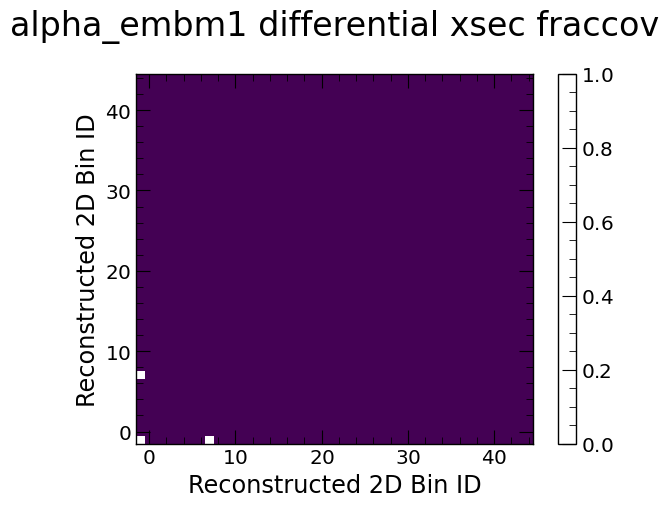

In [170]:
for s in [csystematics_rw,msystematics_rw,dsystematics_rw]:
  s.plot_all_covariance_matrices(plot_dir=f'{PLOT_DIR}/syst/')

## Testing

In [190]:
fname = '/exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/mc_syst/v4/mc_singlepand_slimsyst_nocuts_norecomb2.df'
h5 = h5py.File(fname,'r')
h5.keys()

<KeysViewHDF5 ['evt_pand_0', 'hdr_0', 'histgenevtdf_0', 'histpotdf_0', 'mcnu_0', 'split']>

In [ ]:
df = pd.read_hdf(fname,key='evt_pand_0')

In [ ]:
with open('/exp/sbnd/app/users/brindenc/develop/cafpyana/analysis_village/numuincl/slc_slimsyst_keys.txt','w') as f:
  for k in df.truth.keys():
    f.write(f'{k}\n')

In [53]:
import uproot
fname = 'root://fndcadoor.fnal.gov:1094/pnfs/fnal.gov/usr/sbn/data_add/sbn_nd/poms_production/mc/MCP2025B_v10_06_00_09/v10_06_00_09/prodgenie_corsika_proton_rockbox_sbnd/CV/caf/a7/8e/caf.flat.caf-fe76de92-7dd6-4677-9304-5f8a1d2927d7.root'
tree = uproot.open(fname)
tree.keys()

['env;1',
 'env/envtree;2',
 'env/envtree;1',
 'globalTree;2',
 'globalTree;1',
 'TotalPOT;1',
 'TotalEvents;1',
 'TotalGenEvents;1',
 'recTree;1',
 'GenieEvtRecTree;1',
 'metadata;1',
 'metadata/metatree;1']

In [58]:
tree['globalTree/global/wgts/wgts.name'].arrays(library='np')

{'wgts.name': array([array(['GENIEReWeight_SBN_v1_multisigma_ZExpA1CCQE',
               'GENIEReWeight_SBN_v1_multisigma_ZExpA2CCQE',
               'GENIEReWeight_SBN_v1_multisigma_ZExpA3CCQE',
               'GENIEReWeight_SBN_v1_multisigma_ZExpA4CCQE',
               'GENIEReWeight_SBN_v1_multisigma_VecFFCCQEshape',
               'GENIEReWeight_SBN_v1_multisigma_RPA_CCQE',
               'GENIEReWeight_SBN_v1_multisigma_CoulombCCQE',
               'GENIEReWeight_SBN_v1_multisigma_NormCCMEC',
               'GENIEReWeight_SBN_v1_multisigma_NormNCMEC',
               'GENIEReWeight_SBN_v1_multisigma_DecayAngMEC',
               'GENIEReWeight_SBN_v1_multisigma_MaNCEL',
               'GENIEReWeight_SBN_v1_multisigma_EtaNCEL',
               'GENIEReWeight_SBN_v1_multisigma_MaCCRES',
               'GENIEReWeight_SBN_v1_multisigma_MvCCRES',
               'GENIEReWeight_SBN_v1_multisigma_MaNCRES',
               'GENIEReWeight_SBN_v1_multisigma_MvNCRES',
               'GENIEReWeigh

In [522]:
import uproot
bugfix_fname = 'root://fndcadoor.fnal.gov:1094/pnfs/fnal.gov/usr/sbnd/persistent/users/apapadop/GENIETweakedSamples/v3_6_2_AR23_20i_00_000_liang_bugfix/14_1000180400_CC_v3_6_2_AR23_20i_00_000.flat.root'
tree = uproot.open(bugfix_fname)
df_bf = tree['FlatTree_VARS'].arrays(library='pd')

nominal_fname = 'root://fndcadoor.fnal.gov:1094/pnfs/fnal.gov/usr/sbnd/persistent/users/apapadop/GENIETweakedSamples/v3_6_2_AR23_20i_00_000/14_1000180400_CC_v3_6_2_AR23_20i_00_000.flat.root'
tree = uproot.open(nominal_fname)
df_nom = tree['FlatTree_VARS'].arrays(library='pd')

In [536]:
df_nom.keys()

Index(['Mode', 'GENIEResCode', 'cc', 'PDGnu', 'Enu_true', 'tgt', 'tgta',
       'tgtz', 'PDGLep', 'ELep', 'CosLep', 'Q2', 'q0', 'q3', 'Enu_QE', 'Q2_QE',
       'W_nuc_rest', 'W', 'W_genie', 'x', 'y', 'Erecoil_minerva',
       'Erecoil_charged', 'EavAlt', 'Emiss', 'pmiss', 'Emiss_preFSI',
       'pmiss_preFSI', 'CosThetaAdler', 'PhiAdler', 'dalphat', 'dpt', 'dphit',
       'pnreco_C', 'nfsp', 'px', 'py', 'pz', 'E', 'pdg', 'pdg_rank', 'ninitp',
       'px_init', 'py_init', 'pz_init', 'E_init', 'pdg_init', 'nvertp',
       'px_vert', 'py_vert', 'pz_vert', 'E_vert', 'pdg_vert', 'Weight',
       'InputWeight', 'RWWeight', 'fScaleFactor', 'CustomWeight',
       'CustomWeightArray', 'flagCCINC', 'flagNCINC', 'flagCCQE', 'flagCC0pi',
       'flagCCQELike', 'flagNCEL', 'flagNC0pi', 'flagCCcoh', 'flagNCcoh',
       'flagCC1pip', 'flagNC1pip', 'flagCC1pim', 'flagNC1pim', 'flagCC1pi0',
       'flagNC1pi0', 'flagCC0piMINERvA', 'flagCC0Pi_T2K_AnaI',
       'flagCC0Pi_T2K_AnaII'],
      dtype='object

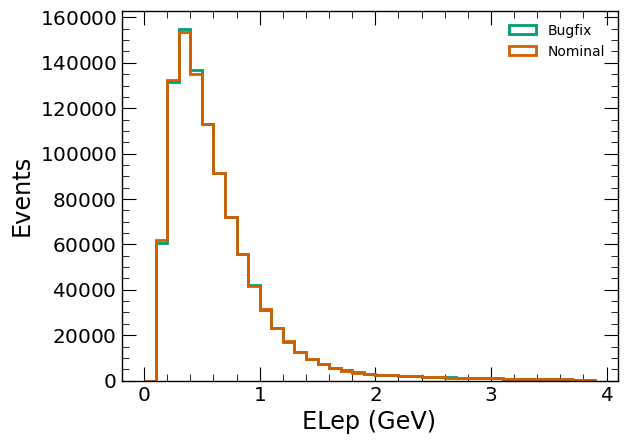

In [ ]:
#np.arange(0,4,.1)
plt.hist([df_nom['ELep'],df_bf['ELep']],bins=np.arange(0,4,.1),label=['Nominal','Bugfix'],histtype='step');
plt.legend();
plt.xlabel('ELep (GeV)');
plt.ylabel('Events');

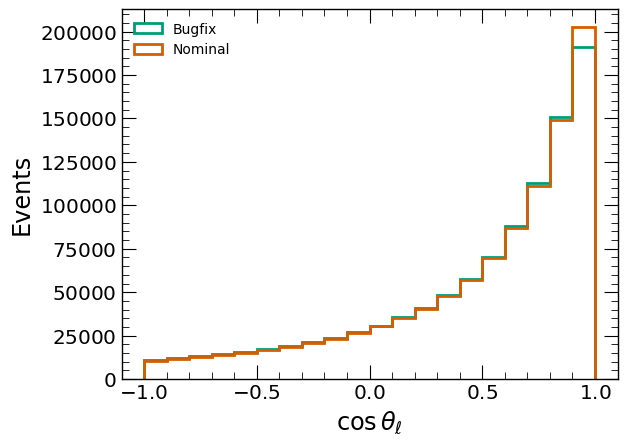

In [541]:
plt.hist([df_nom['CosLep'],df_bf['CosLep']],bins=np.arange(-1,1.1,.1),label=['Nominal','Bugfix'],histtype='step');
plt.legend();
plt.xlabel(r'$\cos\theta_\ell$');
plt.ylabel('Events');

In [812]:
from analysis_village.unfolding.wienersvd import WienerSVD

print("=== Test 1: Perfect Case ===")
n_bins = 5
identity_response = np.eye(n_bins)
identity_response[1,0] = 0.1
test_signal = np.array([100.0, 100.0, 100.0, 100.0, 100.0])
test_measured = test_signal.copy()  # Same as signal
test_measured[1] = 1000.0
test_cov = np.diag(test_signal)*100  # Identity covariance

result1 = WienerSVD(identity_response, test_signal, test_measured, test_cov, 0, 0.0)
print(f"Unfolded result: {result1['unfold']}")
print(f"Should equal signal: {np.allclose(result1['unfold'], test_signal)}")
print(f"AddSmear should be identity: {np.allclose(result1['AddSmear'], np.eye(n_bins))}")
print("AddSmear matrix:")
print(result1['AddSmear'])
print(f"AddSmear diagonal: {np.diag(result1['AddSmear'])}")
print(f"AddSmear column sums: {np.sum(result1['AddSmear'], axis=0)}")

=== Test 1: Perfect Case ===
-Response: [[1.  0.  0.  0.  0. ]
 [0.1 1.  0.  0.  0. ]
 [0.  0.  1.  0.  0. ]
 [0.  0.  0.  1.  0. ]
 [0.  0.  0.  0.  1. ]]
-Signal: [100. 100. 100. 100. 100.]
-Measure: [ 100. 1000.  100.  100.  100.]
-Covariance: [[10000.     0.     0.     0.     0.]
 [    0. 10000.     0.     0.     0.]
 [    0.     0. 10000.     0.     0.]
 [    0.     0.     0. 10000.     0.]
 [    0.     0.     0.     0. 10000.]]
-C_type: 0
-Norm_type: 0.0
-U_cov: [[1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1.]]
-s_cov: [10000. 10000. 10000. 10000. 10000.]
-Q0: [[1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1.]]
-Q: [[0.01 0.   0.   0.   0.  ]
 [0.   0.01 0.   0.   0.  ]
 [0.   0.   0.01 0.   0.  ]
 [0.   0.   0.   0.01 0.  ]
 [0.   0.   0.   0.   0.01]]
-M_trans: [ 1. 10.  1.  1.  1.]
-R: [[0.01  0.    0.    0.    0.   ]
 [0.001 0.01  0.    0.    0.   ]
 [0.    0.    0.01  0.    0.   ]
 [0.    0.    0

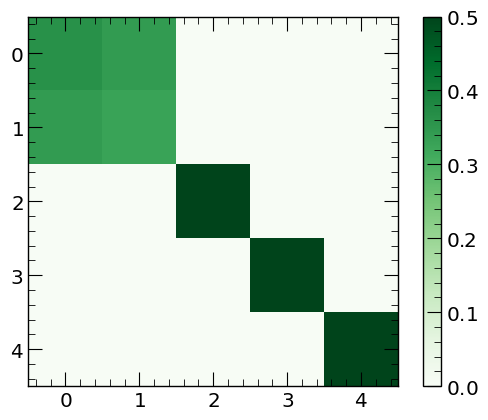

In [813]:
plt.imshow(result1['AddSmear'])
plt.colorbar()

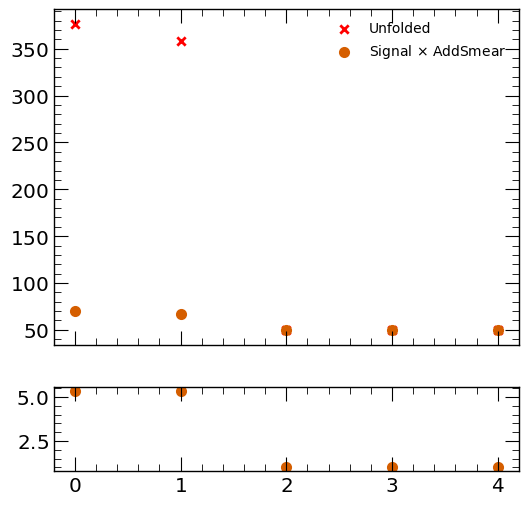

In [814]:
fig,(ax1,ax2) = plt.subplots(2,1,figsize=(6,6),sharex=True,height_ratios=[4,1])
ax1.scatter(np.arange(n_bins),result1['unfold'],marker='x',color='red',label='Unfolded')
ax1.scatter(np.arange(n_bins),test_signal@result1['AddSmear'],label=r'Signal $\times$ AddSmear')
ax2.scatter(np.arange(n_bins),result1['unfold']/(test_signal@result1['AddSmear']))
ax1.legend()


In [808]:
_inter = inter.copy()

In [282]:
flux_keys = list(set([k[1] for k in _inter.data.keys() if 'Flux' in k[1]]))
with open('flux_keys.txt','w') as f:
  f.write(str(flux_keys))
flux_keys


['pionqexsec_Flux',
 'kplus_Flux',
 'pioninexsec_Flux',
 'nucleontotxsec_Flux',
 'nucleoninexsec_Flux',
 'horncurrent_Flux',
 'piplus_Flux',
 'piontotxsec_Flux',
 'kminus_Flux',
 'expskin_Flux',
 'nucleonqexsec_Flux',
 'Flux',
 'piminus_Flux',
 'kzero_Flux']

In [271]:
genie_keys = list(set([k[1] for k in slc.data.keys() if 'GENIE' in k[1]]))
genie_keys

['GENIEReWeight_SBN_v1_multisigma_NormNCMEC',
 'GENIEReWeight_SBN_v1_multisigma_ThetaDelta2NRad',
 'GENIEReWeight_SBN_v1_multisigma_NonRESBGvnCC2pi',
 'GENIEReWeight_SBN_v1_multisigma_RDecBR1eta',
 'GENIE',
 'GENIEReWeight_SBN_v1_multisigma_NonRESBGvbarpCC1pi',
 'GENIEReWeight_SBN_v1_multisigma_NonRESBGvnCC1pi',
 'GENIEReWeight_SBN_v1_multisigma_NonRESBGvpNC2pi',
 'GENIEReWeight_SBN_v1_multisigma_NormNCCOH',
 'GENIEReWeight_SBN_v1_multisigma_NonRESBGvbarnNC1pi',
 'GENIEReWeight_SBN_v1_multisigma_NormCCCOH',
 'GENIEReWeight_SBN_v1_multisigma_NonRESBGvpCC1pi',
 'GENIEReWeight_SBN_v1_multisigma_NonRESBGvpNC1pi',
 'GENIEReWeight_SBN_v1_multisigma_Theta_Delta2Npi',
 'GENIEReWeight_SBN_v1_multisigma_NonRESBGvpCC2pi',
 'GENIEReWeight_SBN_v1_multisigma_RDecBR1gamma',
 'GENIEReWeight_SBN_v1_multisigma_NonRESBGvbarpCC2pi',
 'GENIEReWeight_SBN_v1_multisigma_VecFFCCQEshape',
 'GENIEReWeight_SBN_v1_multisigma_DecayAngMEC',
 'GENIEReWeight_SBN_v1_multisigma_NonRESBGvbarnNC2pi',
 'GENIEReWeight_SBN_v

In [83]:
_inter.add_stat_unc()

Generating event seeds: 100%|██████████| 309285/309285 [00:02<00:00, 110934.58it/s]


Successfully generated 309285 unique seeds


Generating universes: 100%|██████████| 100/100 [01:41<00:00,  1.02s/it]


In [86]:
_inter.data.truth.stat.univ_0.value_counts(normalize=True)

univ_0
1.0    0.367936
0.0    0.367386
2.0    0.184655
3.0    0.061238
4.0    0.015167
5.0    0.002971
6.0    0.000566
7.0    0.000061
8.0    0.000019
Name: proportion, dtype: float64

In [160]:
fname = f'{os.path.join(DATA_DIR,"small/mc_small_syst_postprocess_cut.df")}'
#df = pd.read_hdf(fname,key='evt_0')

In [38]:
list(df.keys())

[('id', '', '', '', '', ''),
 ('is_cathode_crosser_x', '', '', '', '', ''),
 ('is_contained_x', '', '', '', '', ''),
 ('is_fiducial_x', '', '', '', '', ''),
 ('is_flash_matched', '', '', '', '', ''),
 ('is_truth', '', '', '', '', ''),
 ('num_particles_x', '', '', '', '', ''),
 ('num_primary_particles_x', '', '', '', '', ''),
 ('vertex', 'x', '', '', '', ''),
 ('vertex', 'y', '', '', '', ''),
 ('vertex', 'z', '', '', '', ''),
 ('flash_hypo_pe', '', '', '', '', ''),
 ('flash_total_pe', '', '', '', '', ''),
 ('match_overlaps', '', '', '', '', ''),
 ('current_type', '', '', '', '', ''),
 ('energy_init', '', '', '', '', ''),
 ('energy_transfer', '', '', '', '', ''),
 ('num_particles_y', '', '', '', '', ''),
 ('num_primary_particles_y', '', '', '', '', ''),
 ('inelasticity', '', '', '', '', ''),
 ('interaction_mode', '', '', '', '', ''),
 ('interaction_type', '', '', '', '', ''),
 ('is_cathode_crosser_y', '', '', '', '', ''),
 ('is_contained_y', '', '', '', '', ''),
 ('is_fiducial_y', '', ''

In [161]:
with h5py.File(fname, 'r') as f:
    keys = list(f.keys())  # Convert the KeysViewWithLock object to a list for easier viewing
    print(keys)

['mcnu', 'pandora', 'pandora_signal', 'spine', 'spine_signal']
